## Human Activity Recognition for Healthy Lifestyle Monitoring

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


Import Libraries:

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [2]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
import  shutil
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

from data_loader import *
from visualization import *
from preprocessing import *

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

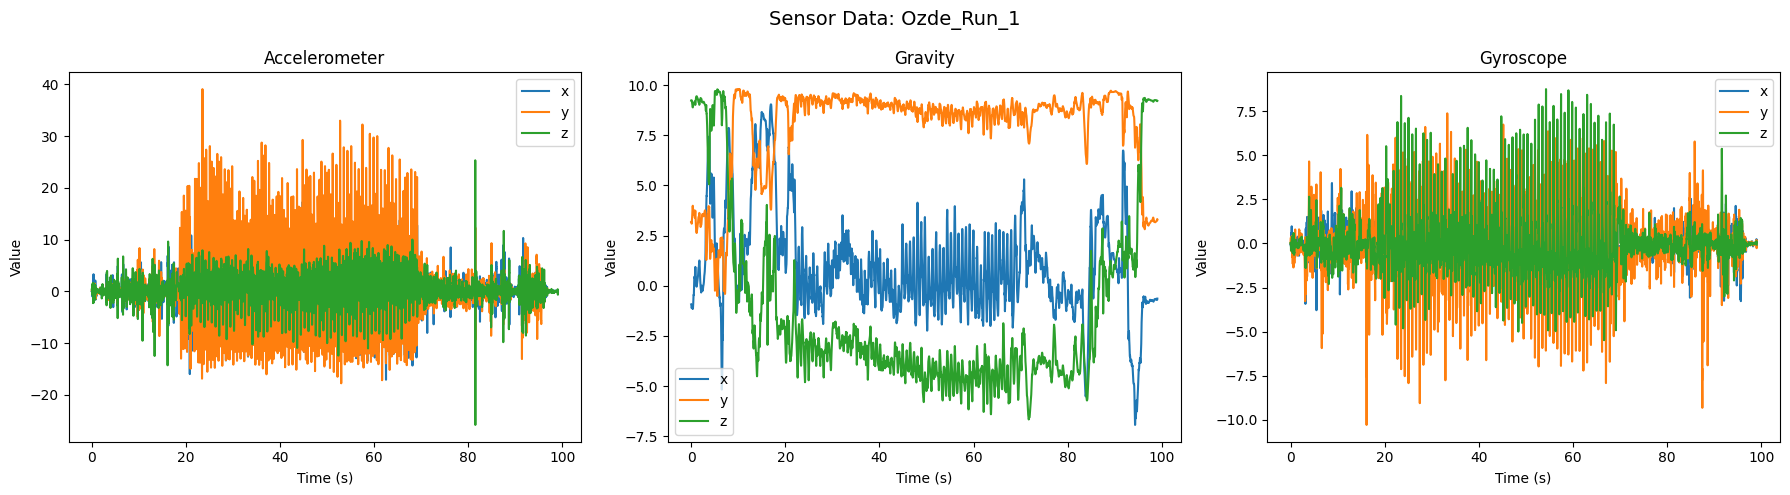

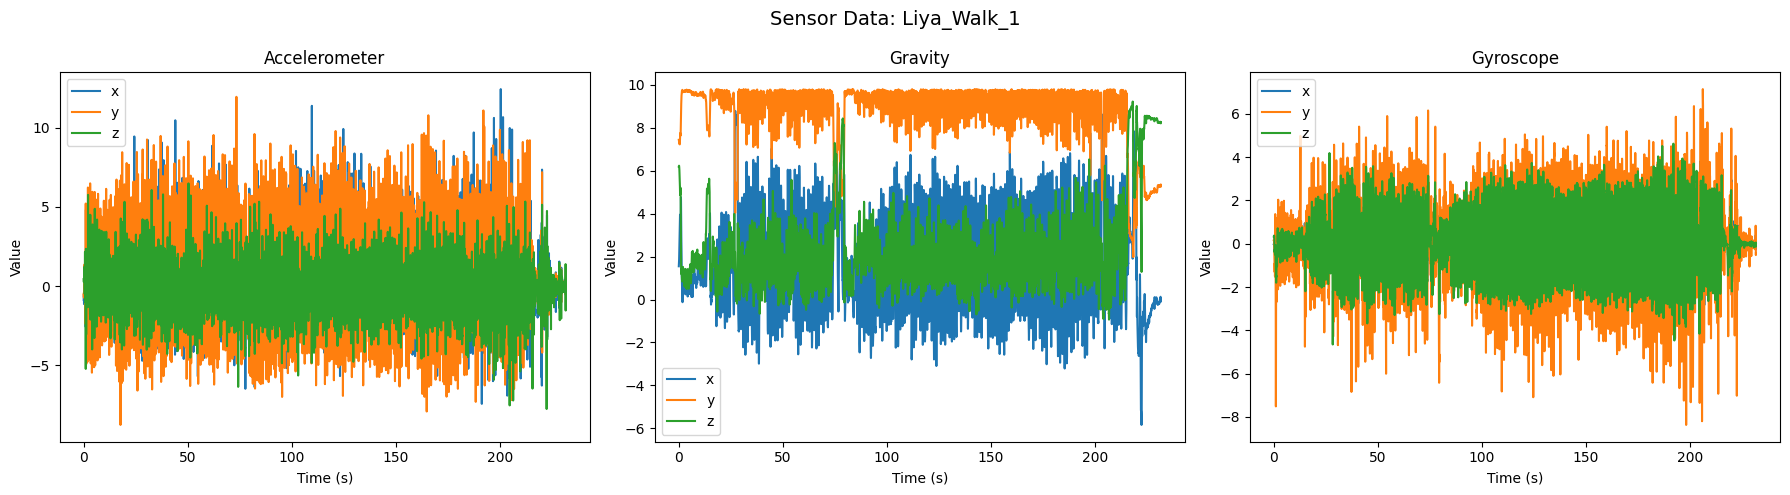

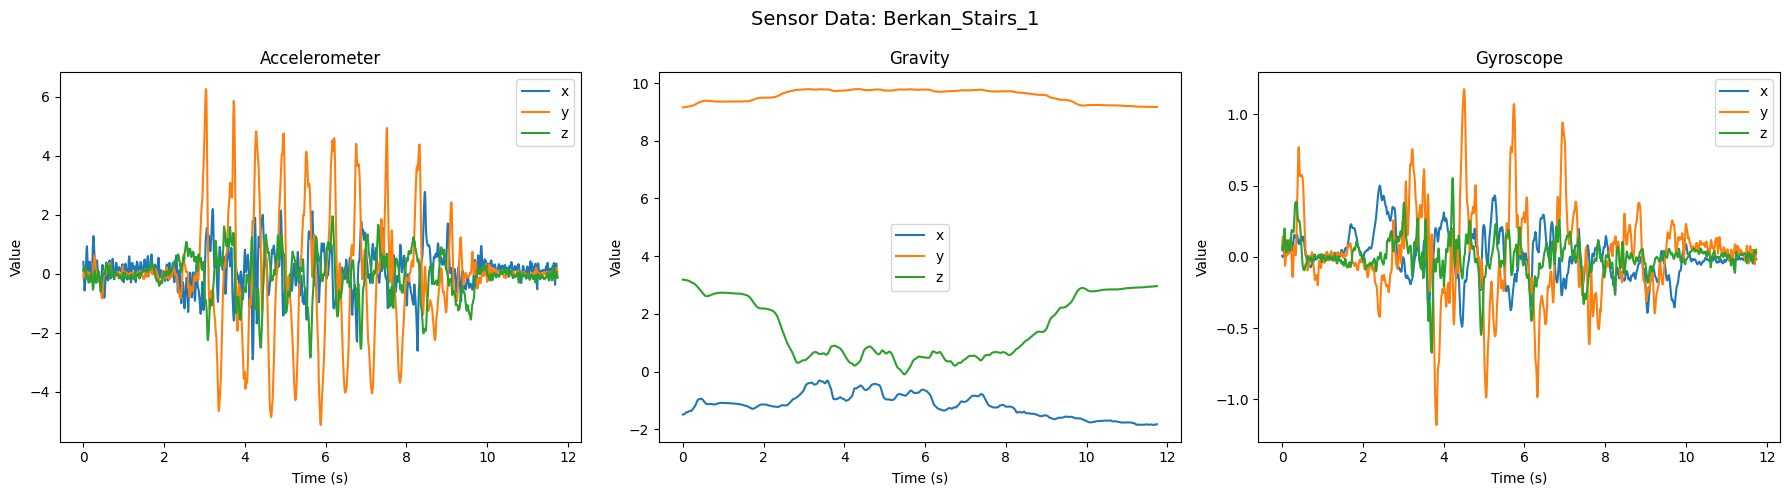

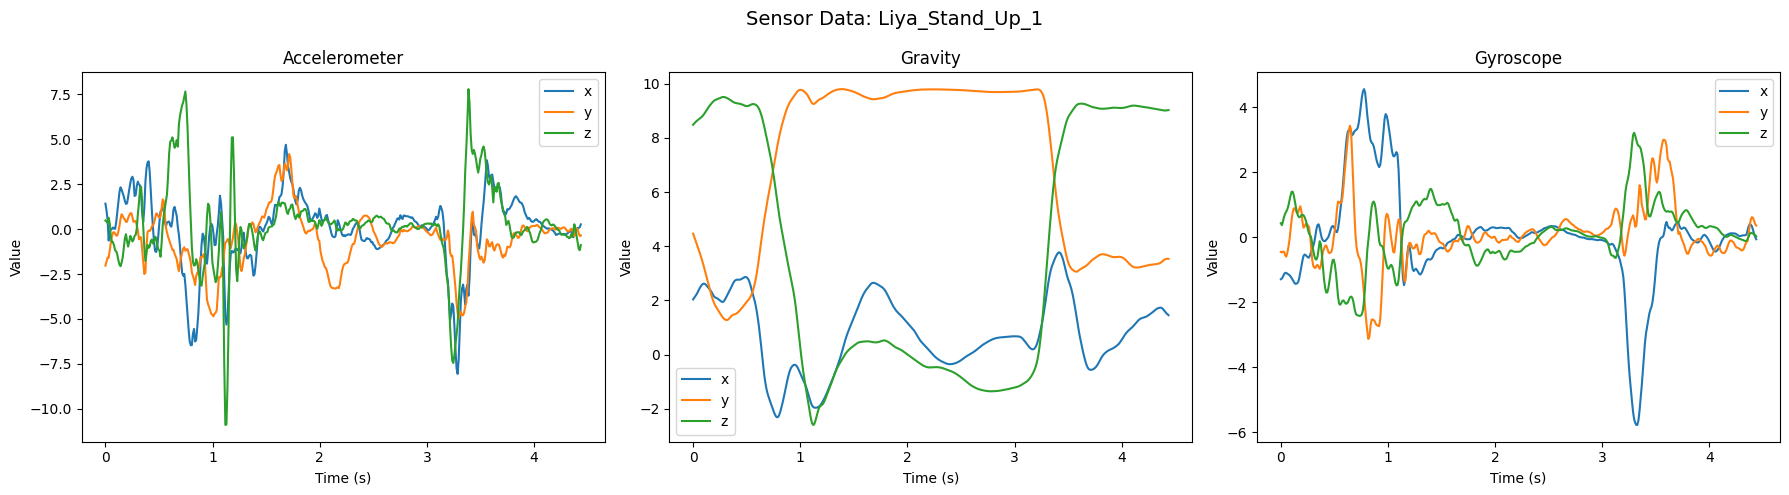

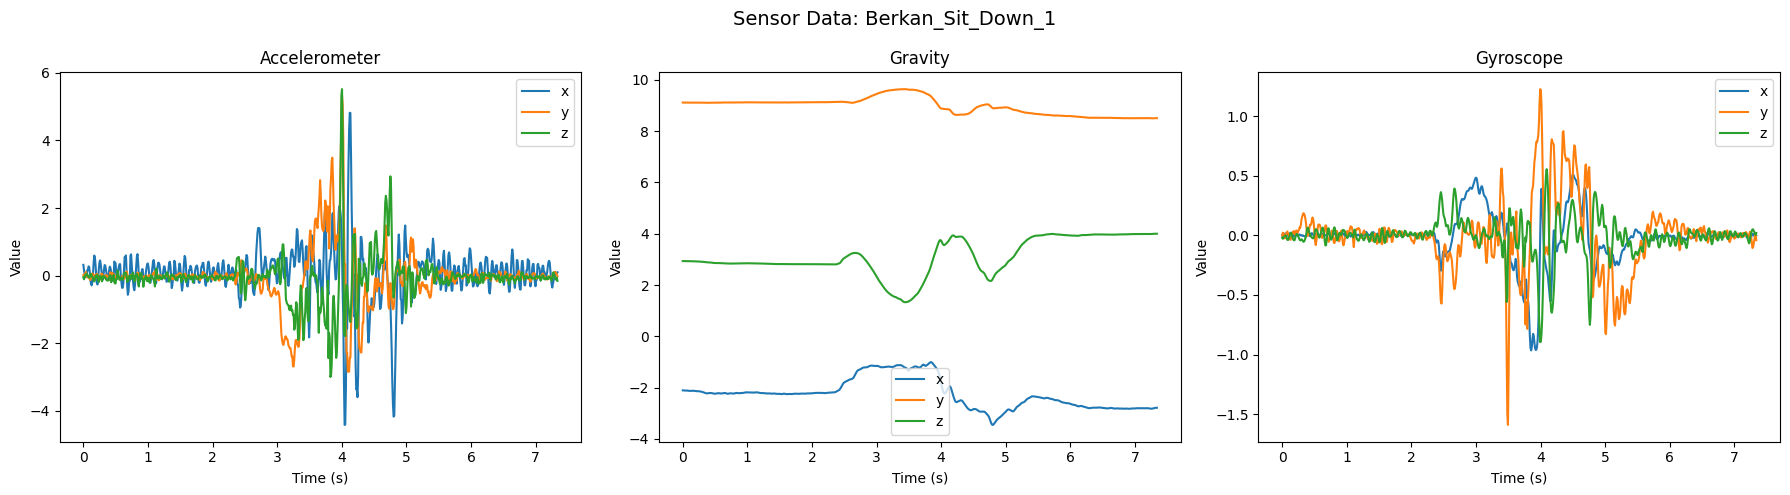

In [3]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

- **For Continuous activities (running / walking / climbing stairs):** 
The preprocess_running, preprocess_walking, and preprocess_stairs functions all prepare the raw sensor recordings by detecting the active motion period and slicing it into fixed-length windows (3 s with 50% overlap). Each function first computes the RMS energy of the accelerometer (or gravity for stairs) to identify the start and end trim points, removing idle segments before and after the activity. Then, the trimmed data is split into overlapping windows for consistent input to later feature extraction and modeling. For walking and running, trimming is based on the accelerometer’s vertical axis, while for stairs it uses the gravity signal for more stable detection. These functions also generate plots showing the trimmed segments and shaded windows to visually verify the preprocessing steps.

In [4]:
WINDOW_SIZE = 3.0 #Seconds

# change show_plots to True to visualize the preprocessing steps

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 79.21, 39 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_data/running

 Processing running | Folder: Ozde_Run_5
  Trim 17.97 → 91.14, 47 windows, saved in /Users/liyaboro/Desktop/uni/Master/Q1/DA&LM/VS - DA&LM/Data-Analytics-and-Learning-Methods/data/trimmed_da

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

During motion (like walking or running), the accelerometer RMS is higher than during rest.
By sliding a window over the signal and comparing its RMS to these thresholds, we can automatically trim away the idle periods before and after the actual activity.

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)



The corresponding accelerometer plots with the trims marked based on the RMS plot analysis. It can be seen that the trims capture the main activity by capturing the central part of the accelerometer data and leaving out the noise present at the start and end.

Walking:

![](figures/walk_rms.jpg)

![](figures/walk_acc.jpg)

Running: 

![](figures/run_rms.jpg)

![](figures/run_acc.jpg)

Stairs:

![](figures/rms_intersection.png)

![](figures/stairs_overlap.png)



- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments. As before, we base this on the activity’s total energy.

In [5]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 157 | Skipped: 0


The trimming process for siting down and standing up functions:

- looping over both activities
- normalizing each recording's timestamps so they all start at 0.
- the trim is detected by analyzing the y-axis of the gravity sensor since it clearly shifts between the transitioning of the movements sitting and standing up.
- RMS calculation over hort windows is claculated and treshold values are defined for the start and end of the trim which are used to make the necessery cuts.

Now we can collect all windowed activity data into a single CSV file.

Using the windowed x, y, and z-axis recordings from the three sensors, we extracted the following features: acc_corr_x_y, acc_corr_x_z, acc_corr_y_z, acc_mag_dom_freq, acc_mag_iqr, acc_mag_kurtosis, acc_mag_max, acc_mag_mean, acc_mag_median, acc_mag_min, acc_mag_rms, acc_mag_skew, acc_mag_spec_centroid, acc_mag_spec_energy, acc_mag_spec_entropy, acc_mag_std, …, gyro_y_spec_entropy, gyro_y_std, gyro_z_dom_freq, gyro_z_iqr, gyro_z_kurtosis, gyro_z_max, gyro_z_mean, gyro_z_median, gyro_z_min, gyro_z_rms, gyro_z_skew, gyro_z_spec_centroid, gyro_z_spec_energy, gyro_z_spec_entropy, and gyro_z_std. 

which corresponds to 166 features per windowed sample.

These samples were compiled into a dataset for subsequent analysis and modeling.

In [6]:
from create_csv import *

DATASET_PATH = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windowed_data(TRIMMED_BASE, DATASET_PATH, keep_ids=True)

[Audit]
  - running: expected=276, usable=276, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=79, usable=79, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=82, usable=82, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=78, usable=78, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 996 | Usable (all three files OK): 996

[Activity] running
  Processed 250 windows...

[Activity] sit_down

[Activity] stairs

[Activity] stand_up
  Processed 500 windows...

[Activity] walking
  Processed 750 windows...

[Done] Wrote 996 rows × 167 columns to: /U

## Load the dataset
- First column is label (y)
- Remaining are features (X)

In [7]:
DATASET_PATH = PROJECT_ROOT / "dataset.csv"

df = pd.read_csv(DATASET_PATH)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", X.shape[1])

df.head(3)# 12345

Loaded dataset.csv with shape: (996, 167)
Target name: activity
Num features: 166


,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,person
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-0.017501,-0.035374,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,0.038710,0.124412,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,0.085773,0.187724,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [8]:
# imports
from sklearn.preprocessing import StandardScaler
from preprocessing import stratified_person_label_split

X_train, y_train, X_test, y_test, info = stratified_person_label_split(X,y,test_ratio=0.20,random_state=42)

print(info["sizes"])
print(info["ratios"])
print("Classes:", info["class_dist"])
print("People:", info["person_dist"])

# --- StandardScaler setup ---
scaler = StandardScaler()

print(X_train.dtypes)
print(X_train.head())

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Scale numeric features only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test.index)


{'train': 797, 'test': 199, 'total': 996}
{'train': 0.8002008032128514, 'test': 0.19979919678714858}
Classes: {'train': {'running': 221, 'sit_down': 63, 'stairs': 66, 'stand_up': 62, 'walking': 385}, 'test': {'running': 55, 'sit_down': 16, 'stairs': 16, 'stand_up': 16, 'walking': 96}}
People: {'train': {'Berkan': 172, 'Liya': 336, 'Ozde': 289}, 'test': {'Berkan': 43, 'Liya': 83, 'Ozde': 73}}
acc_corr_x_y            float64
acc_corr_x_z            float64
acc_corr_y_z            float64
acc_mag_dom_freq        float64
acc_mag_iqr             float64
                         ...   
gyro_z_spec_centroid    float64
gyro_z_spec_energy      float64
gyro_z_spec_entropy     float64
gyro_z_std              float64
person                   object
Length: 166, dtype: object
     acc_corr_x_y  acc_corr_x_z  acc_corr_y_z  acc_mag_dom_freq  acc_mag_iqr  \
832     -0.108411     -0.054293      0.084811          1.683502     1.651833   
105      0.463551     -0.472952     -0.448733          4.983389   

# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [24]:
## Imports & Code Paths 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, learning_curve
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.decomposition import PCA
from functools import partial
from sklearn.metrics import accuracy_score, silhouette_score 
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


# Our feature selection toolkit (from feature_selection.py)
from feature_selection import (
    filter_select,
    wrapper_select,
    plot_correlation_heatmap,
    accuracy_vs_k_MI
)

import os
# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [25]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 108, Removed: 57 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_mean', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_iqr', 'grav_mag_median', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_median', 'grav_y_rms', 'grav_y_std', 'grav_z_max', 'grav_z_mean', 'grav_z_median', 'grav_z_min', 'grav_z_std', 'gyro_mag_max', 'gyro_mag_mean', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_iqr', 'gyro_y_max', 'gyro_y_min', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_iqr', 'gyro_z_max', 'gyro_z_min', 'gyro_z_r

Baseline CV performance (5-fold, training set only):

LogisticRegression:
  Accuracy : 0.9695 ± 0.0147
  Kappa    : 0.9541 ± 0.0218
  F1-macro : 0.9322 ± 0.0324


  File "c:\Users\ozdep\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(



KNN:
  Accuracy : 0.9580 ± 0.0131
  Kappa    : 0.9364 ± 0.0197
  F1-macro : 0.9079 ± 0.0289

NaiveBayes:
  Accuracy : 0.9135 ± 0.0181
  Kappa    : 0.8718 ± 0.0261
  F1-macro : 0.8399 ± 0.0165

DecisionTree:
  Accuracy : 0.9491 ± 0.0114
  Kappa    : 0.9235 ± 0.0167
  F1-macro : 0.8913 ± 0.0221


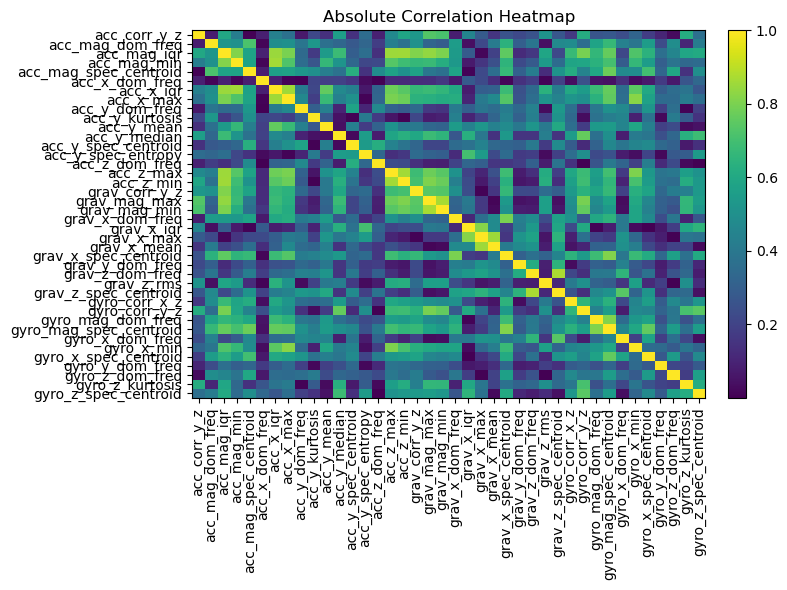

Saved correlation heatmap to corr_heatmap.png


In [26]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Define custom scorers
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": make_scorer(f1_score, average="macro")  # macro for multiclass
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Baseline CV performance (5-fold, training set only):")
for name, clf in models.items():
    cv_results = cross_validate(clf, X_train_fs.values, y_train, cv=cv, scoring=scorers)
    acc_mean, acc_std = cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
    kappa_mean, kappa_std = cv_results["test_kappa"].mean(), cv_results["test_kappa"].std()
    f1_mean, f1_std = cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()

    print(f"\n{name}:")
    print(f"  Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Kappa    : {kappa_mean:.4f} ± {kappa_std:.4f}")
    print(f"  F1-macro : {f1_mean:.4f} ± {f1_std:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 128, Removed: 37 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_max (r=0.951)
  acc_mag_iqr -> acc_mag_mean (r=0.968)
  acc_mag_max -> acc_mag_mean (r=0.953)
  acc_mag_mean -> acc_mag_median (r=0.993)
  acc_mag_iqr -> acc_mag_rms (r=0.976)
  acc_mag_max -> acc_mag_rms (r=0.966)
 

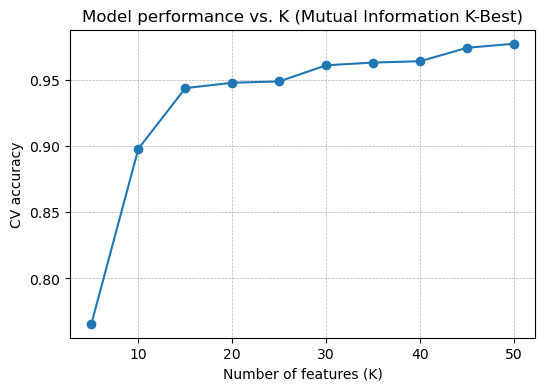

Saved MI K-curve to figures/mi_k_curve.png


In [27]:
# Keep only numeric features
X_num = X.select_dtypes(include=["number"])

# MI curve
ks, accs = accuracy_vs_k_MI(
    X_num, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")

## Wrapper Methods
XXXXX

In [28]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
features_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    cv_splits=5,
    choose_by="accuracy"
)

[RFE] k=40 start | Acc 0.9695 | F1m 0.9322 | Kappa 0.9541
[RFE] eliminated: grav_y_dom_freq | k=39 | Acc 0.9695 | F1m 0.9322 | Kappa 0.9541
[RFE] eliminated: acc_x_dom_freq | k=38 | Acc 0.9669 | F1m 0.9276 | Kappa 0.9503
[RFE] eliminated: grav_x_dom_freq | k=37 | Acc 0.9657 | F1m 0.9245 | Kappa 0.9484
[RFE] eliminated: grav_mag_min | k=36 | Acc 0.9657 | F1m 0.9231 | Kappa 0.9483
[RFE] eliminated: gyro_corr_x_z | k=35 | Acc 0.9682 | F1m 0.9293 | Kappa 0.9521
[RFE] eliminated: gyro_z_dom_freq | k=34 | Acc 0.9695 | F1m 0.9324 | Kappa 0.9541
[RFE] eliminated: grav_x_iqr | k=33 | Acc 0.9669 | F1m 0.9276 | Kappa 0.9503
[RFE] eliminated: gyro_x_dom_freq | k=32 | Acc 0.9695 | F1m 0.9340 | Kappa 0.9541
[RFE] eliminated: grav_z_dom_freq | k=31 | Acc 0.9707 | F1m 0.9357 | Kappa 0.9559
[RFE] eliminated: gyro_corr_y_z | k=30 | Acc 0.9707 | F1m 0.9357 | Kappa 0.9559
[RFE] eliminated: gyro_y_dom_freq | k=29 | Acc 0.9707 | F1m 0.9356 | Kappa 0.9560
[RFE] eliminated: gyro_z_kurtosis | k=28 | Acc 0.9733

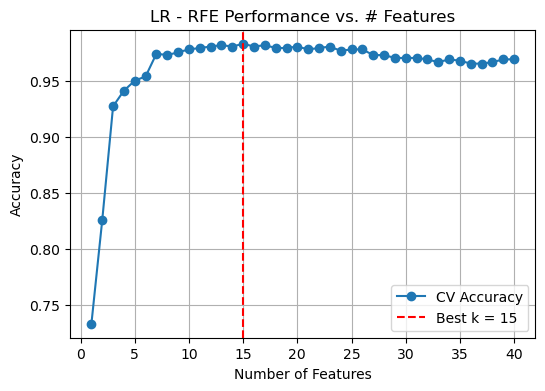

In [29]:
# Extract performance history
steps = [h["k"] for h in info_lr["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_lr["history"]]
best_k = info_lr["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"LR - {info_lr['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
features_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    estimator=KNeighborsClassifier(n_neighbors=5),
    cv_splits=5,
    choose_by="accuracy"
)

[SFS:forward] added: gyro_mag_dom_freq | k=1 | Acc 0.8435 | F1m 0.5978 | Kappa 0.7596
[SFS:forward] added: acc_y_spec_centroid | k=2 | Acc 0.8702 | F1m 0.7765 | Kappa 0.8037
[SFS:forward] added: acc_x_iqr | k=3 | Acc 0.9402 | F1m 0.8810 | Kappa 0.9088
[SFS:forward] added: acc_mag_iqr | k=4 | Acc 0.9542 | F1m 0.9011 | Kappa 0.9305
[SFS:forward] added: grav_x_mean | k=5 | Acc 0.9644 | F1m 0.9206 | Kappa 0.9459
[SFS:forward] added: acc_mag_dom_freq | k=6 | Acc 0.9720 | F1m 0.9369 | Kappa 0.9576
[SFS:forward] added: acc_y_median | k=7 | Acc 0.9771 | F1m 0.9449 | Kappa 0.9654
[SFS:forward] added: grav_x_spec_centroid | k=8 | Acc 0.9784 | F1m 0.9484 | Kappa 0.9673
[SFS:forward] added: acc_mag_min | k=9 | Acc 0.9796 | F1m 0.9520 | Kappa 0.9692
[SFS:forward] added: acc_x_max | k=10 | Acc 0.9784 | F1m 0.9496 | Kappa 0.9673
[SFS:forward] added: grav_corr_y_z | k=11 | Acc 0.9797 | F1m 0.9520 | Kappa 0.9692
[SFS:forward] added: grav_x_iqr | k=12 | Acc 0.9784 | F1m 0.9485 | Kappa 0.9674
[SFS:forwar

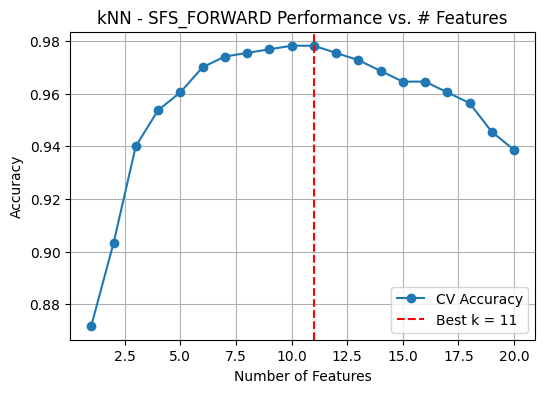

In [75]:
# Extract performance history
steps = [h["k"] for h in info_knn["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_knn["history"]]
best_k = info_knn["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"kNN - {info_knn['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Wrapper: SFS (forward) + Naive Bayes
features_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    estimator=GaussianNB(),
    cv_splits=5,
    choose_by="accuracy"
)

[SFS:forward] added: acc_mag_iqr | k=1 | Acc 0.8377 | F1m 0.4530 | Kappa 0.7068
[SFS:forward] added: acc_mag_spec_centroid | k=2 | Acc 0.8909 | F1m 0.6790 | Kappa 0.8159
[SFS:forward] added: gyro_y_iqr | k=3 | Acc 0.9414 | F1m 0.8258 | Kappa 0.9044
[SFS:forward] added: gyro_corr_y_z | k=4 | Acc 0.9468 | F1m 0.8463 | Kappa 0.9133
[SFS:forward] added: acc_y_dom_freq | k=5 | Acc 0.9523 | F1m 0.8517 | Kappa 0.9225
[SFS:forward] added: acc_mag_min | k=6 | Acc 0.9564 | F1m 0.8739 | Kappa 0.9294
[SFS:forward] added: gyro_mag_dom_freq | k=7 | Acc 0.9591 | F1m 0.8872 | Kappa 0.9337
[SFS:forward] added: acc_y_median | k=8 | Acc 0.9591 | F1m 0.8872 | Kappa 0.9347
[SFS:forward] added: acc_x_dom_freq | k=9 | Acc 0.9591 | F1m 0.9033 | Kappa 0.9347
[SFS:forward] added: gyro_mag_spec_centroid | k=10 | Acc 0.9591 | F1m 0.8971 | Kappa 0.9347
[SFS:forward] added: acc_z_dom_freq | k=11 | Acc 0.9591 | F1m 0.8989 | Kappa 0.9346
[SFS:forward] added: gyro_y_dom_freq | k=12 | Acc 0.9577 | F1m 0.9018 | Kappa 0.

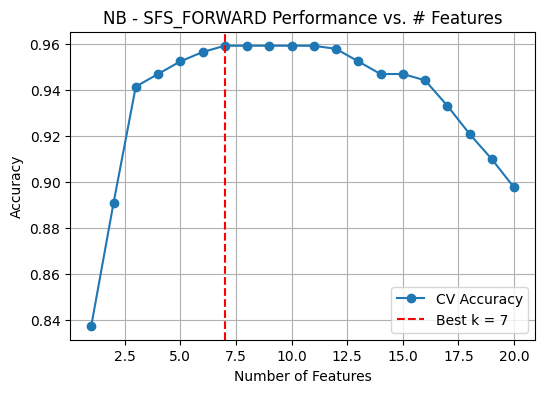

In [76]:
# Extract performance history
steps = [h["k"] for h in info_nb["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_nb["history"]]
best_k = info_nb["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"NB - {info_nb['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
features_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    estimator=DecisionTreeClassifier(random_state=42),
    cv_splits=5,
    choose_by="accuracy"
)

[RFE] k=20 start | Acc 0.9509 | F1m 0.8706 | Kappa 0.9211
[RFE] eliminated: acc_x_dom_freq | k=19 | Acc 0.9496 | F1m 0.8713 | Kappa 0.9194
[RFE] eliminated: acc_y_dom_freq | k=18 | Acc 0.9536 | F1m 0.8884 | Kappa 0.9261
[RFE] eliminated: acc_x_iqr | k=17 | Acc 0.9496 | F1m 0.8627 | Kappa 0.9196
[RFE] eliminated: grav_x_spec_centroid | k=16 | Acc 0.9509 | F1m 0.8735 | Kappa 0.9217
[RFE] eliminated: grav_x_dom_freq | k=15 | Acc 0.9537 | F1m 0.8840 | Kappa 0.9257
[RFE] eliminated: acc_z_dom_freq | k=14 | Acc 0.9577 | F1m 0.8948 | Kappa 0.9328
[RFE] eliminated: grav_y_dom_freq | k=13 | Acc 0.9564 | F1m 0.8875 | Kappa 0.9303
[RFE] eliminated: grav_z_dom_freq | k=12 | Acc 0.9577 | F1m 0.8960 | Kappa 0.9327
[RFE] eliminated: gyro_x_dom_freq | k=11 | Acc 0.9550 | F1m 0.8858 | Kappa 0.9282
[RFE] eliminated: gyro_y_dom_freq | k=10 | Acc 0.9564 | F1m 0.8906 | Kappa 0.9303
[RFE] eliminated: gyro_mag_dom_freq | k=9 | Acc 0.9536 | F1m 0.8814 | Kappa 0.9260
[RFE] eliminated: gyro_z_dom_freq | k=8 | A

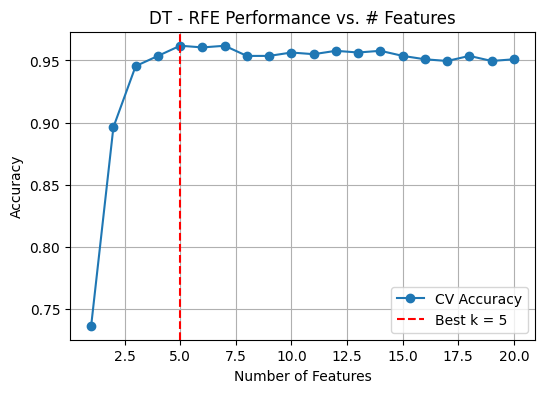

In [77]:
# Extract performance history
steps = [h["k"] for h in info_dt["history"]]
accs = [h["metrics"]["accuracy"][0] for h in info_dt["history"]]
best_k = info_dt["best"]["k"]

plt.figure(figsize=(6,4))
plt.plot(steps, accs, marker='o', linestyle='-', label='CV Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f"DT - {info_dt['method'].upper()} Performance vs. # Features")
plt.legend()
plt.grid(True)
plt.show()

### Creating subsets with the selected features per model

In [56]:
# 1) Collect the per-model selected feature names
feature_sets = {
    "lr":  features_lr,   # from wrapper RFE + Logistic Regression
    "knn": features_knn,  # from wrapper SFS + KNN
    "nb":  features_nb,   # from wrapper SFS + Naive Bayes
    "dt":  features_dt,   # from wrapper RFE + Decision Tree
}

# 2) Create subsets directly (train/test; add val block if you have it)
X_train_lr = X_train_scaled[feature_sets["lr"]]
X_test_lr  = X_test_scaled[feature_sets["lr"]]

X_train_knn = X_train_scaled[feature_sets["knn"]]
X_test_knn  = X_test_scaled[feature_sets["knn"]]

X_train_nb = X_train_scaled[feature_sets["nb"]]
X_test_nb  = X_test_scaled[feature_sets["nb"]]

X_train_dt = X_train_scaled[feature_sets["dt"]]
X_test_dt  = X_test_scaled[feature_sets["dt"]]

print("Subset sizes (rows = samples, cols = features):")
print(f"  LR  → train: {X_train_lr.shape}, test: {X_test_lr.shape}")
print(f"  KNN → train: {X_train_knn.shape}, test: {X_test_knn.shape}")
print(f"  NB  → train: {X_train_nb.shape}, test: {X_test_nb.shape}")
print(f"  DT  → train: {X_train_dt.shape}, test: {X_test_dt.shape}")

Subset sizes (rows = samples, cols = features):
  LR  → train: (733, 13), test: (182, 13)
  KNN → train: (733, 11), test: (182, 11)
  NB  → train: (733, 7), test: (182, 7)
  DT  → train: (733, 5), test: (182, 5)


# Supervised Learning Methods

Different supervised learning methods are trained:
- A Logistic Regression model (LR)
- A Decision Tree (DT)
- A Naive Bayes classifier (NB)
- K-Nearest Neighbor algorithm (kNN)

Each of these is trained using their own subset of features which were selected during the feature selection phase.

Every model is trained using cross-validation adn is evaluated using the three scorers: Accuracy, Cohen's Kappa, and F1-score, as been done earlier in the notebook too.

For every model, their respective hyperparameters are tuned using gridsearch.

In [57]:
# CELL 1 — shared setup (run once)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

# Scorers: accuracy, Cohen's kappa, and macro-F1 for 5-class setup
scorers = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": "f1_macro",
}

# pick one of these
refit_metric = "kappa"      
# refit_metric = "f1_macro"  
# refit_metric = "accuracy"  

# 5-fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def summarize_grid_search(gs):
    print("Best params:", gs.best_params_)
    print("Refit scorer:", gs.refit)
    print("Best CV score (refit metric):", gs.best_score_)

    # Show mean CV scores for all scorers at the best params
    means = gs.cv_results_["mean_test_accuracy"][gs.best_index_], \
            gs.cv_results_["mean_test_kappa"][gs.best_index_], \
            gs.cv_results_["mean_test_f1_macro"][gs.best_index_]
    print({"mean_accuracy": means[0], "mean_kappa": means[1], "mean_f1_macro": means[2]})


In [58]:
# CELL 2 — Logistic Regression
# Use your model-specific training frame with 15 selected features
# X_logreg_train: pandas DataFrame of shape (n_samples, 15)
# y_train: 1D array-like of class labels (5 classes)

from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        #class_weight="balanced",
        random_state=42 ))
])

param_grid_lr = {
    "clf__C": np.logspace(-3, 2, 10),          # 0.001 ... 100
    "clf__max_iter": [500, 1000, 2000, 5000],  # convergence budget
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_lr.fit(X_train_lr, y_train)
summarize_grid_search(gs_lr)

best_logreg = gs_lr.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'clf__C': np.float64(7.742636826811277), 'clf__max_iter': 500}
Refit scorer: kappa
Best CV score (refit metric): 0.9607230653275988
{'mean_accuracy': np.float64(0.9754822476935979), 'mean_kappa': np.float64(0.9607230653275988), 'mean_f1_macro': np.float64(0.9346898207538133)}


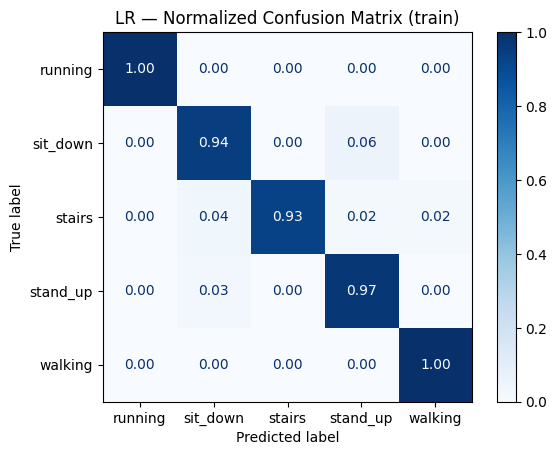

,feature,mean_abs_coef,mean_signed_coef
0,acc_mag_iqr,2.621794,-3.907985e-15
1,acc_y_median,2.246079,3.730349e-15
2,gyro_y_iqr,1.880663,-2.042810e-15
3,acc_mag_spec_centroid,1.868547,-3.641532e-15
4,acc_mag_min,1.514932,-7.482903e-15
5,grav_x_spec_centroid,1.341857,-4.130030e-15
6,gyro_corr_y_z,1.274389,4.174439e-15
7,gyro_mag_dom_freq,1.177576,-1.987299e-15
8,acc_x_iqr,1.176672,-2.264855e-15
9,gyro_mag_spec_centroid,1.076587,-6.461498e-15


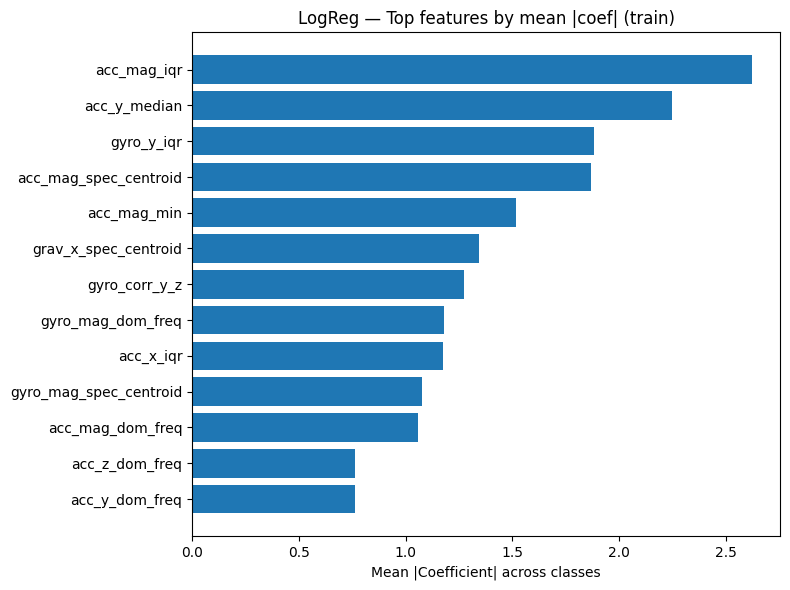

In [59]:
# Logistic Regression — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_logreg, X_train_lr, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("LR — Normalized Confusion Matrix (train)")
plt.show()

# 2) Mean coefficients across classes (top features)
lr = best_logreg.named_steps["clf"] if hasattr(best_logreg, "named_steps") else best_logreg
coefs = lr.coef_  # shape: (n_classes, n_features)

feature_names = list(getattr(X_train_lr, "columns", [f"f{i}" for i in range(coefs.shape[1])]))
mean_abs = np.mean(np.abs(coefs), axis=0)
mean_signed = np.mean(coefs, axis=0)

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_coef": mean_abs,
        "mean_signed_coef": mean_signed,
    })
    .sort_values("mean_abs_coef", ascending=False)
    .reset_index(drop=True)
)

# Show top 15
display(coef_df.head(15))

# Optional: bar plot for top features by mean |coef|
top = coef_df.head(15).sort_values("mean_abs_coef", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["mean_abs_coef"])
plt.xlabel("Mean |Coefficient| across classes")
plt.title("LogReg — Top features by mean |coef| (train)")
plt.tight_layout()
plt.show()


In [60]:
# CELL 3 — Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(2, 31, 2)),
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

gs_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_dt.fit(X_train_dt, y_train)
summarize_grid_search(gs_dt)

best_dt = gs_dt.best_estimator_

print("Depth:", best_dt.get_depth())
print("Leaves:", best_dt.get_n_leaves())


Fitting 5 folds for each of 512 candidates, totalling 2560 fits
Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Refit scorer: kappa
Best CV score (refit metric): 0.9500522883664496
{'mean_accuracy': np.float64(0.9686422514211165), 'mean_kappa': np.float64(0.9500522883664496), 'mean_f1_macro': np.float64(0.9304254163189013)}
Depth: 7
Leaves: 17


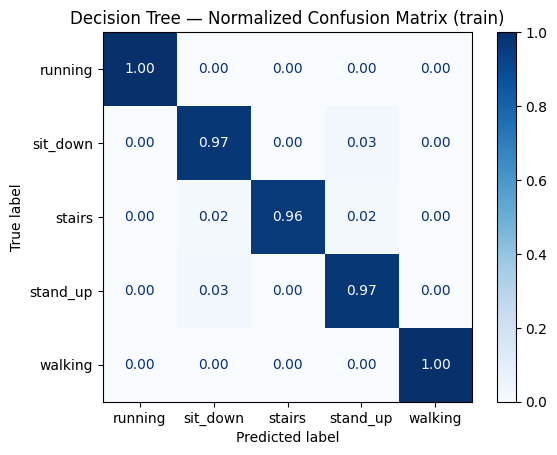

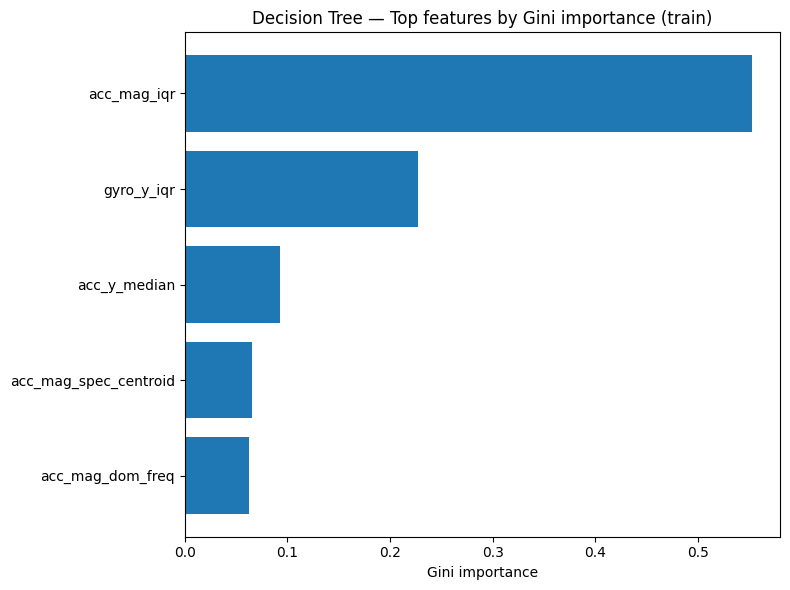

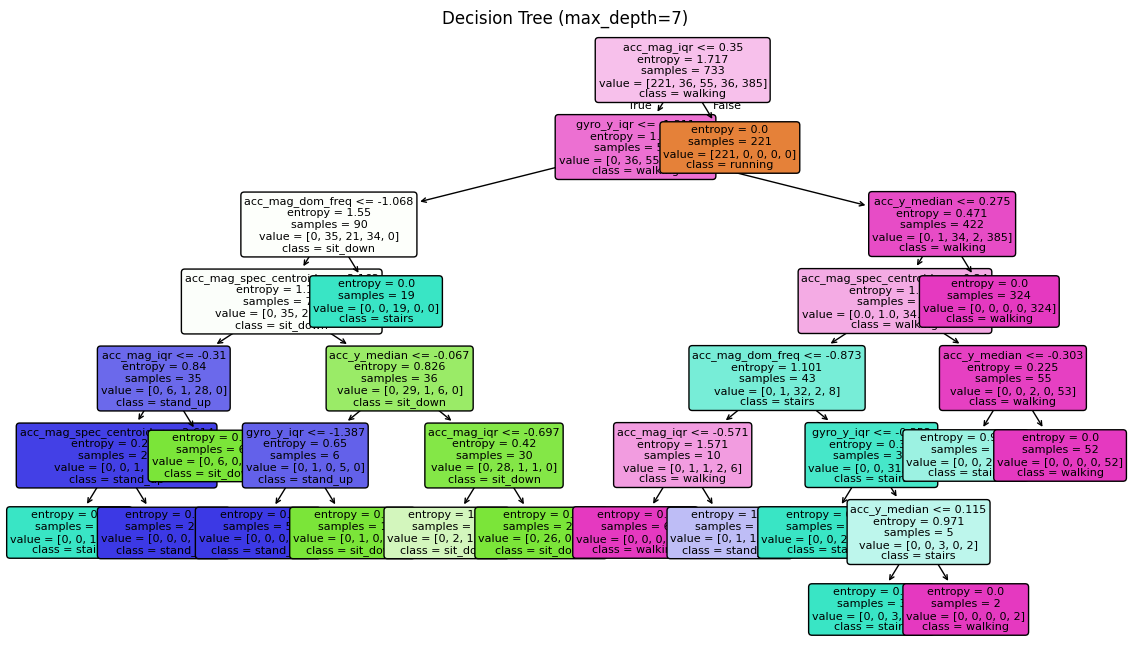

In [68]:
# Decision Tree — train-set evaluation 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import tree as sktree

# 1) Normalized confusion matrix (rows sum to 1)
ConfusionMatrixDisplay.from_estimator(
    best_dt, X_train_dt, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("Decision Tree — Normalized Confusion Matrix (train)")
plt.show()

# 2) Gini importances + bar plot
dt = best_dt.named_steps["clf"] if hasattr(best_dt, "named_steps") else best_dt
feature_names = list(getattr(X_train_dt, "columns", [f"f{i}" for i in range(dt.n_features_in_)]))
imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

# bar plot of top 15
top = imp.head(15).sort_values(ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top.values)
plt.xlabel("Gini importance")
plt.title("Decision Tree — Top features by Gini importance (train)")
plt.tight_layout()
plt.show()

# 3) Visualize the tree 
# Tree size was confirmed to be 7 which is not too deep to visualize.
# If you wish to visualize more or less levels change max_depth
plt.figure(figsize=(14, 8))
sktree.plot_tree(
    dt,
    feature_names=feature_names,
    class_names=[str(c) for c in dt.classes_],
    max_depth=7, filled=True, rounded=True, fontsize=8
)
plt.title("Decision Tree (max_depth=7)")
plt.show()



In [69]:
# CELL 4 — Naive Bayes (Gaussian)
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

param_grid_gnb = {
    "var_smoothing": np.logspace(-12, -6, 7)  # 1e-12 ... 1e-6
}

gs_gnb = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid_gnb,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_gnb.fit(X_train_nb, y_train)
summarize_grid_search(gs_gnb)

best_gnb = gs_gnb.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'var_smoothing': np.float64(1e-12)}
Refit scorer: kappa
Best CV score (refit metric): 0.933651026017345
{'mean_accuracy': np.float64(0.9591091231012954), 'mean_kappa': np.float64(0.933651026017345), 'mean_f1_macro': np.float64(0.8871833110504322)}


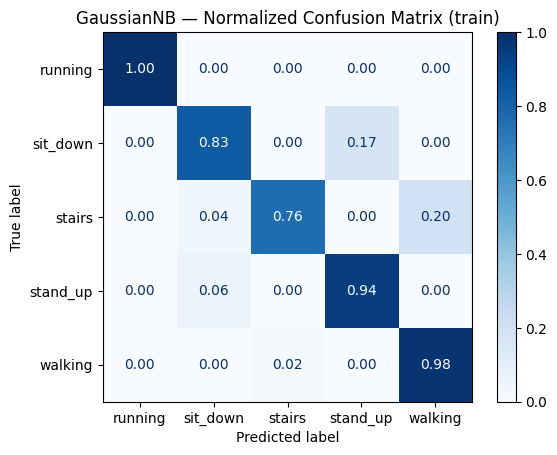

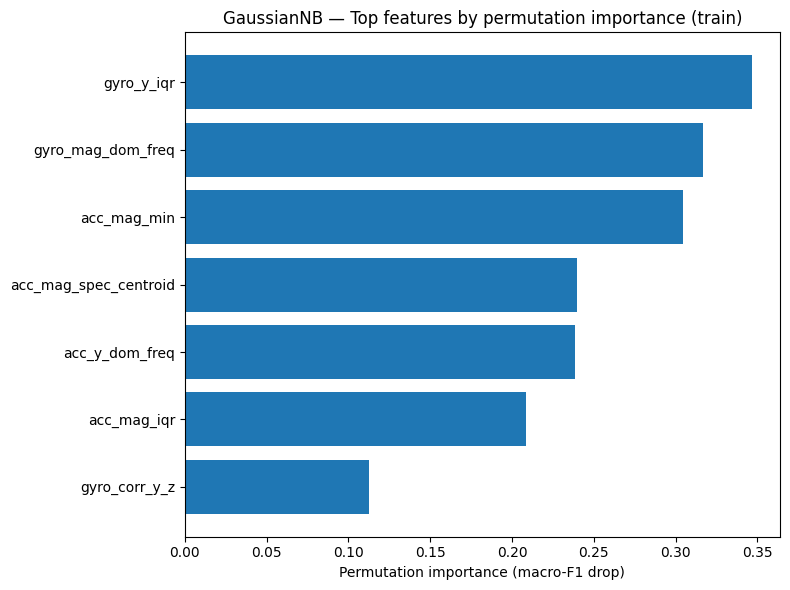

In [70]:
# Gaussian Naive Bayes — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_gnb, X_train_nb, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("GaussianNB — Normalized Confusion Matrix (train)")
plt.show()

# 2) Permutation importance (macro-F1) on train set
result = permutation_importance(
    best_gnb, X_train_nb, y_train,
    n_repeats=20, random_state=42, n_jobs=-1,
    scoring="f1_macro"
)

pi_mean = pd.Series(result.importances_mean, index=list(getattr(X_train_nb, "columns", None)))
pi_std  = pd.Series(result.importances_std,  index=list(getattr(X_train_nb, "columns", None)))
pi_df = (pd.DataFrame({"importance_mean": pi_mean, "importance_std": pi_std})
           .sort_values("importance_mean", ascending=False))

# bar plot of top 15
top = pi_df.head(15).sort_values("importance_mean", ascending=True)
plt.figure(figsize=(8,6))
plt.barh(top.index, top["importance_mean"])
plt.xlabel("Permutation importance (macro-F1 drop)")
plt.title("GaussianNB — Top features by permutation importance (train)")
plt.tight_layout()
plt.show()


In [71]:
# CELL 5 — KNN
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid_knn = {
    "clf__n_neighbors": list(range(1, 36, 2)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # 1=Manhattan, 2=Euclidean
}

gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring=scorers,
    refit=refit_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs_knn.fit(X_train_knn, y_train)
summarize_grid_search(gs_knn)

best_knn = gs_knn.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'clf__n_neighbors': 1, 'clf__p': 1, 'clf__weights': 'uniform'}
Refit scorer: kappa
Best CV score (refit metric): 0.9758752707781643
{'mean_accuracy': np.float64(0.9850060572174076), 'mean_kappa': np.float64(0.9758752707781643), 'mean_f1_macro': np.float64(0.9641853816743893)}


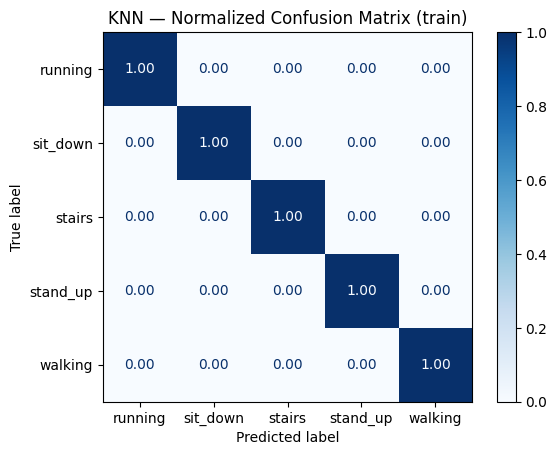

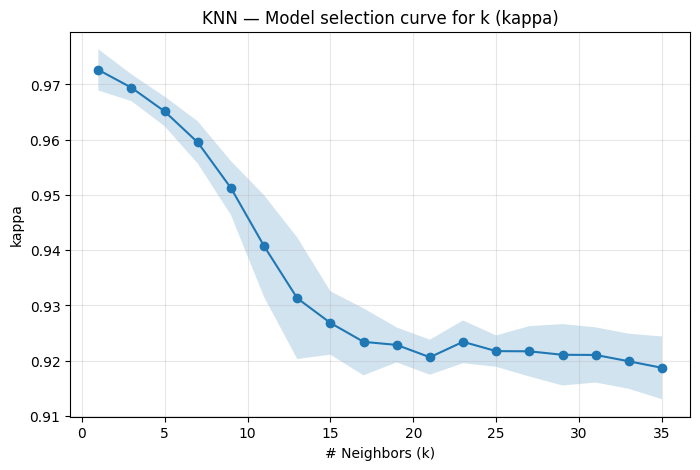

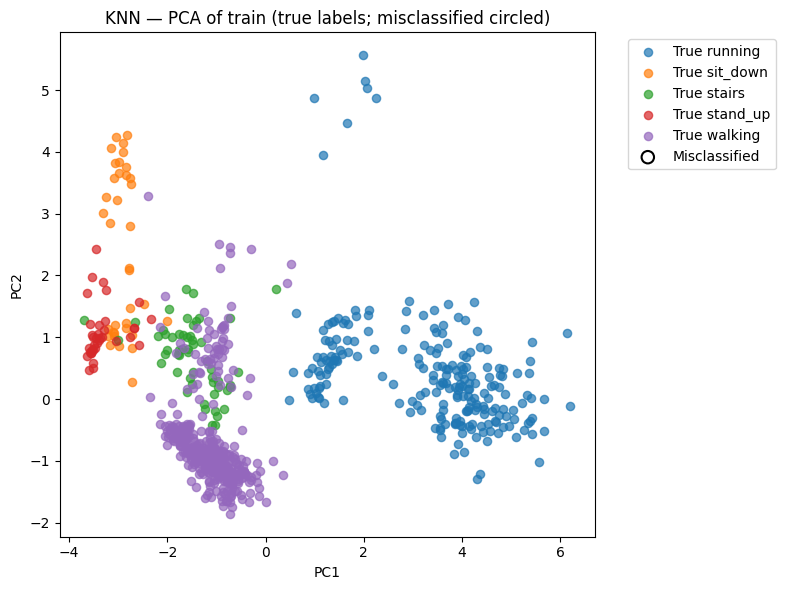

In [72]:
# KNN — train-set evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# 1) Normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_knn, X_train_knn, y_train,
    normalize="true", cmap="Blues", values_format=".2f"
)
plt.title("KNN — Normalized Confusion Matrix (train)")
plt.show()

# 2) Model selection curve for n_neighbors using the refit metric
cvres = pd.DataFrame(gs_knn.cv_results_)
metric = gs_knn.refit  # e.g., "kappa" or "f1_macro"
col = f"mean_test_{metric}"
nn_col = "param_clf__n_neighbors"

curve = (cvres
         .assign(n_neighbors=cvres[nn_col].astype(int))
         .groupby("n_neighbors")[col]
         .agg(["mean", "std"])
         .sort_index())

plt.figure(figsize=(8,5))
plt.plot(curve.index, curve["mean"], marker="o")
plt.fill_between(curve.index, curve["mean"]-curve["std"], curve["mean"]+curve["std"], alpha=0.2)
plt.xlabel("# Neighbors (k)")
plt.ylabel(metric)
plt.title(f"KNN — Model selection curve for k ({metric})")
plt.grid(True, alpha=0.3)
plt.show()

# 3) PCA (2D): true labels vs predicted; misclassified circled
pipe = best_knn  # Pipeline(scaler + KNN)
X_scaled = pipe.named_steps["scaler"].transform(X_train_knn)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

y_pred = pipe.predict(X_train_knn)

unique = np.unique(y_train)
colors = plt.get_cmap("tab10").colors
color_map = {cls: colors[i % len(colors)] for i, cls in enumerate(unique)}

plt.figure(figsize=(8,6))
for i, cls in enumerate(unique):
    mask = (y_train == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=35, alpha=0.7, c=[color_map[cls]], label=f"True {cls}")

mis = (y_pred != y_train)
plt.scatter(X_pca[mis, 0], X_pca[mis, 1], s=80, facecolors="none", edgecolors="k",
            linewidths=1.5, label="Misclassified")

plt.title("KNN — PCA of train (true labels; misclassified circled)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Unsupervised Learning Methods

Different unsupervised learning methods are trained:
- K-Means Clustering
- Fuzzy C-Means Clustering
- Gaussian Mixture Models (GMMs)

In all unsupervised models, a wrapper method is first applied to iterate over candidate feature subsets. The subset selected through this process is then used to train the unsupervised models.

Every model is evaluated using the three scorers: Accuracy, Cohen's Kappa, and F1-score.

Convert Class Labels to Integers:

In [11]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers for metrics
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

### K-Means Clustering

K-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for K-Means Clustering.

Step 1 | +gyro_z_dom_freq | cv_mean=0.799 ± 0.038
Step 2 | +gyro_corr_y_z | cv_mean=0.794 ± 0.037
Step 3 | +grav_corr_y_z | cv_mean=0.795 ± 0.036
Step 4 | +acc_x_dom_freq | cv_mean=0.797 ± 0.029
Step 5 | +acc_corr_y_z | cv_mean=0.827 ± 0.027
Step 6 | +gyro_mag_spec_centroid | cv_mean=0.839 ± 0.039
Step 7 | +acc_mag_iqr | cv_mean=0.836 ± 0.039
Step 8 | +acc_z_dom_freq | cv_mean=0.839 ± 0.038
Step 9 | +gyro_z_spec_centroid | cv_mean=0.829 ± 0.021
Step 10 | +acc_mag_spec_centroid | cv_mean=0.818 ± 0.030
Step 11 | +grav_x_iqr | cv_mean=0.840 ± 0.022
Step 12 | +acc_y_spec_centroid | cv_mean=0.849 ± 0.025
Step 13 | +acc_mag_dom_freq | cv_mean=0.840 ± 0.024
Step 14 | +acc_y_spec_entropy | cv_mean=0.846 ± 0.023
Step 15 | +grav_mag_max | cv_mean=0.847 ± 0.023
Step 16 | +grav_x_dom_freq | cv_mean=0.832 ± 0.036
Step 17 | +gyro_y_dom_freq | cv_mean=0.815 ± 0.073
Step 18 | +acc_y_median | cv_mean=0.835 ± 0.055
Step 19 | +grav_mag_min | cv_mean=0.854 ± 0.021
Step 20 | +acc_y_dom_freq | cv_mean=0.834

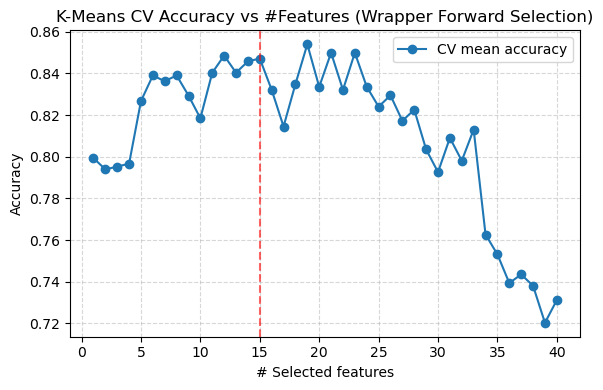

In [42]:
# Denemememememe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from scipy.optimize import linear_sum_assignment


def cluster_accuracy(y_true, y_pred):
    """Accuracy after optimal cluster↔class assignment via Hungarian algorithm."""
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()


def _kmeans_cv_score(X, y, subset, *, k, cv, random_state, kmeans_kwargs):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx][subset].to_numpy(), X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        km = KMeans(n_clusters=k, **kmeans_kwargs, random_state=random_state)
        km.fit(X_tr)
        y_pred = km.predict(X_va)
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_kmeans_accuracy_cv(X_train: pd.DataFrame,
                               y_train: np.ndarray,
                               *,
                               k: int | None = None,
                               n_features_to_select: int = 15,
                               mode: str = "fixed",            # "fixed" → run full; "auto" → early stop on no-improve
                               random_state: int = 31,
                               kmeans_kwargs: dict | None = None,
                               select_set: int = 10,           # which step’s subset to RETURN (int) or "best"
                               cv: int = 5):
    if k is None:
        k = len(np.unique(y_train))
    if kmeans_kwargs is None:
        kmeans_kwargs = {}

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)

        for f in features:
            if f in selected:
                continue

            subset = selected + [f]
            cv_mean, cv_std = _kmeans_cv_score(
                X_train, y_train, subset, k=k, cv=cv,
                random_state=random_state, kmeans_kwargs=kmeans_kwargs
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        # pick feature that maximizes CV mean accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })

        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # Choose subset to RETURN
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]

    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


X_train_km_best, subset_km, best_cv, hist = wrapper_kmeans_accuracy_cv(X_train_fs, 
                                                                    y_train_num,
                                                                    k=5,
                                                                    n_features_to_select=40,
                                                                    mode="fixed",
                                                                    random_state=42,
                                                                    kmeans_kwargs={"n_init": "auto", "max_iter": 300},
                                                                    select_set=15,     # or "best"
                                                                    cv=5)
print("Best subset:", subset_km)
print("Best CV mean accuracy:", best_cv)

# Plot: CV mean only
steps = [h["step"] for h in hist]
cv_means = [h["cv_mean"] for h in hist]
cv_stds  = [h["cv_std"] for h in hist]

plt.figure(figsize=(6,4))
plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_km)  # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("K-Means CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the K-Means Clustering Model


Train Accuracies for k=1..5: {1: 0.5252387448840382, 2: 0.8144611186903138, 3: 0.8390177353342428, 4: 0.8267394270122783, 5: 0.8472032742155525}

K-Means (k=5) - TRAIN Results:
  Accuracy: 0.8472
  F1 Score: 0.6103
  Kappa:    0.7669

K-Means (k=5) - TEST Results:
  Accuracy: 0.8626
  F1 Score: 0.6153
  Kappa:    0.7843


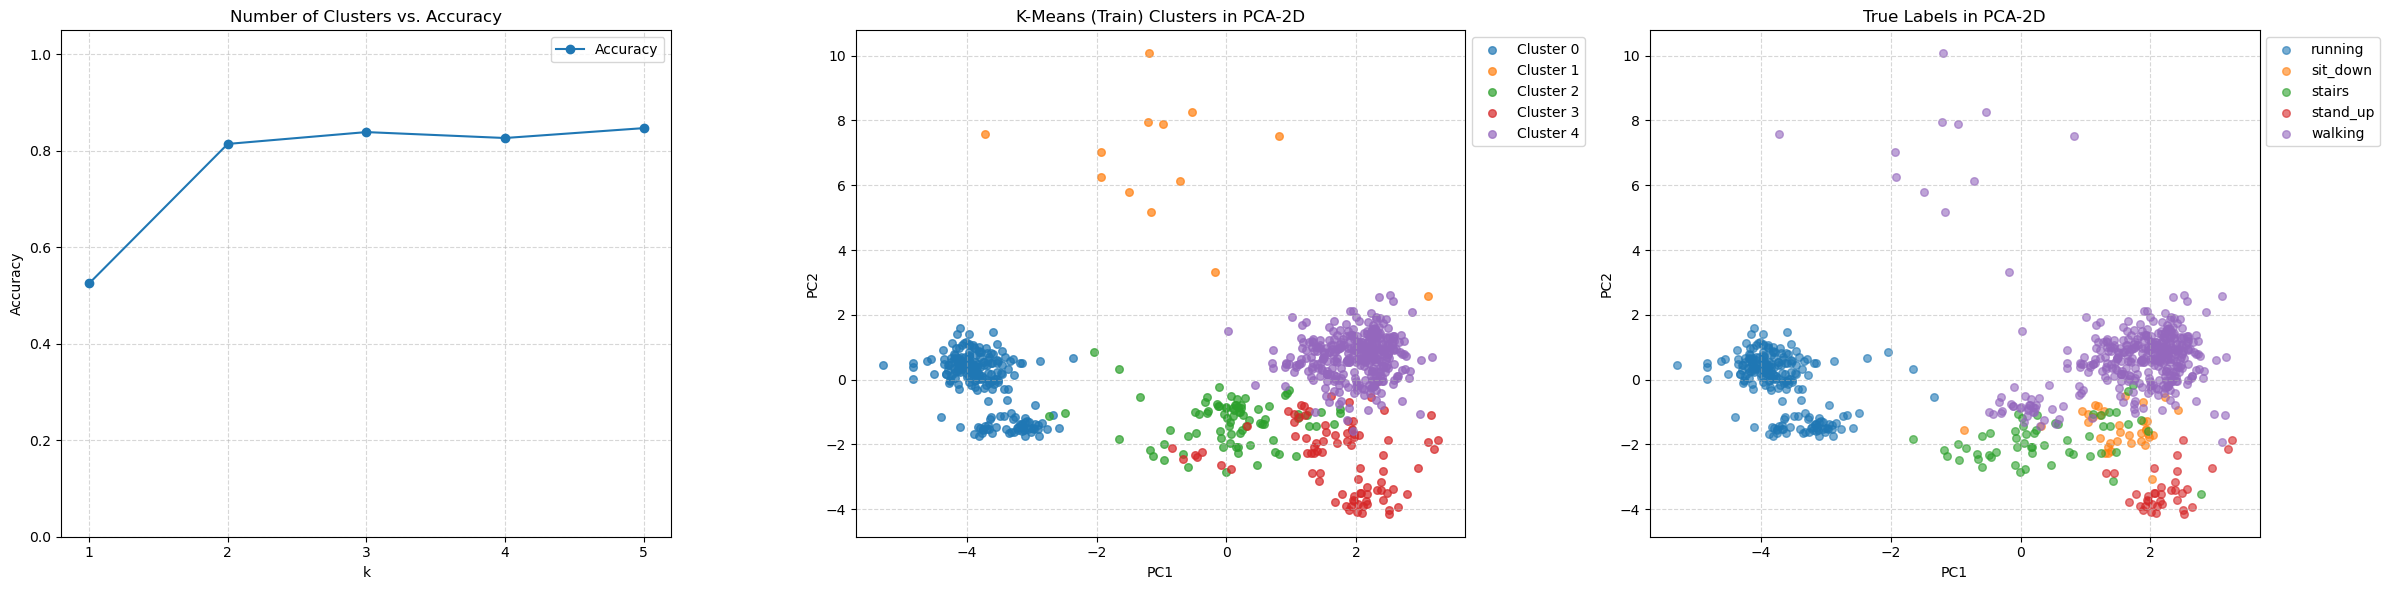

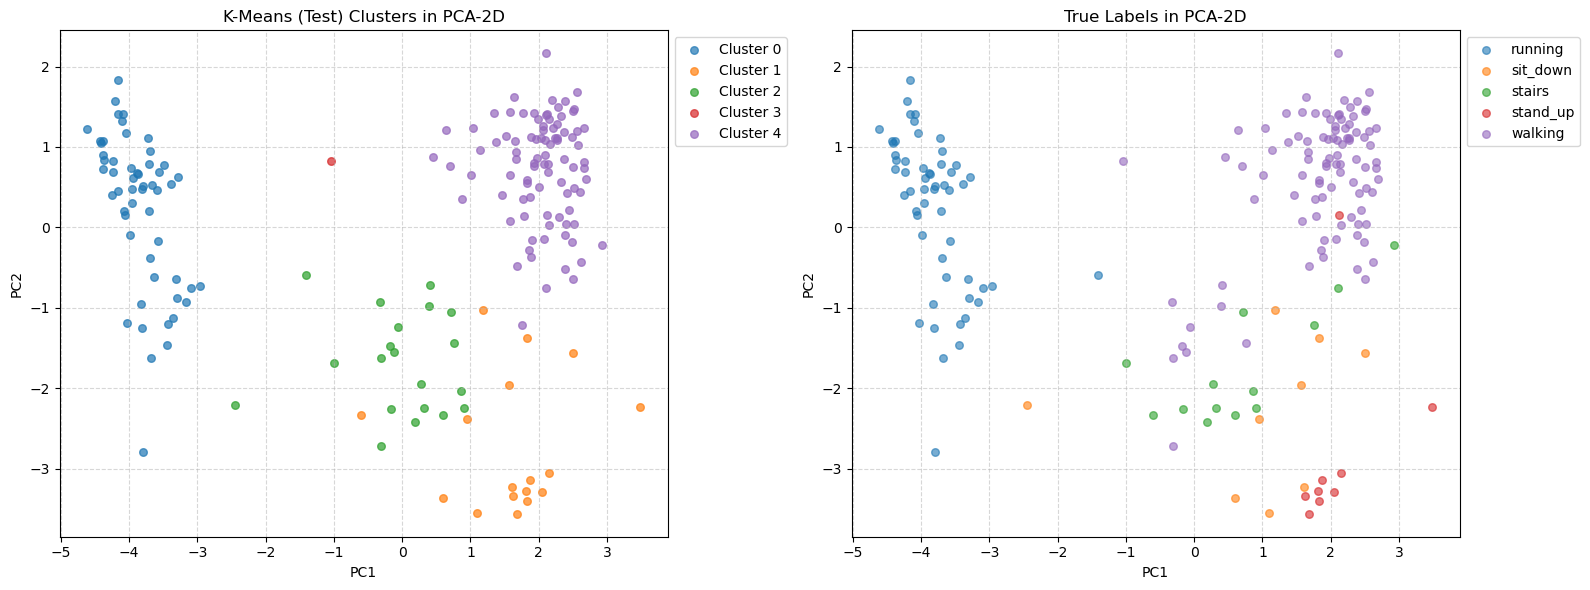

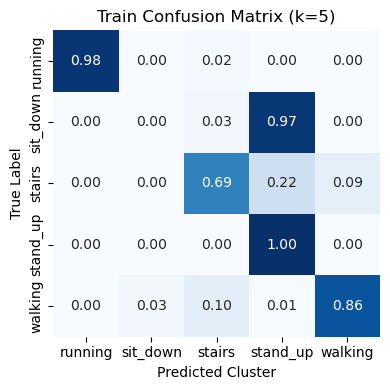

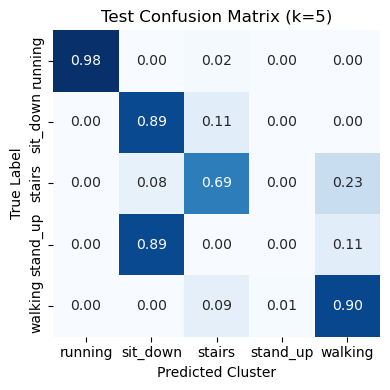

In [43]:
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

def align_clusters(y_true, y_pred):
    """
    Align raw cluster IDs to ground-truth class IDs using Hungarian algorithm.
    """
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)      # maximize matches
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in y_pred])


def eval_model(name, y_true, y_pred):
    """
    Print and return Accuracy, F1-macro and Cohen's Kappa.
    """
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Kappa:    {kappa:.4f}")
    return acc, f1, kappa


def plot_clustering_results(model_name, X_data, y_true, le,
                            cluster_range, accuracies, clusters_k,
                            show_k_vs_acc=True):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    # If we don't want the first plot, make only 2 subplots
    n_cols = 3 if show_k_vs_acc else 2
    fig, axs = plt.subplots(1, n_cols, figsize=(8*n_cols, 6))

    idx = 0
    # --- 1) k vs Accuracy ---
    if show_k_vs_acc:
        axs[0].plot(list(cluster_range), accuracies, marker='o', label="Accuracy")
        axs[0].set_title("Number of Clusters vs. Accuracy")
        axs[0].set_xlabel("k")
        axs[0].set_ylabel("Accuracy")
        axs[0].set_xticks(list(cluster_range))
        axs[0].set_ylim(0, 1.05)
        axs[0].grid(True, linestyle='--', alpha=0.5)
        axs[0].legend()
        idx = 1

    # --- 2) Cluster assignments in PCA space ---
    for c in np.unique(clusters_k):
        pts = X_pca[clusters_k == c]
        axs[idx].scatter(pts[:, 0], pts[:, 1], label=f"Cluster {c}", alpha=0.7, s=30)
    axs[idx].set_title(f"{model_name} Clusters in PCA-2D")
    axs[idx].set_xlabel("PC1")
    axs[idx].set_ylabel("PC2")
    axs[idx].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx].grid(True, linestyle='--', alpha=0.5)

    # --- 3) True labels in PCA space ---
    for lab in np.unique(y_true):
        pts = X_pca[y_true == lab]
        name = str(le.inverse_transform([lab])[0]) if hasattr(le, "inverse_transform") else f"Class {lab}"
        axs[idx+1].scatter(pts[:, 0], pts[:, 1], label=name, alpha=0.6, s=30)
    axs[idx+1].set_title("True Labels in PCA-2D")
    axs[idx+1].set_xlabel("PC1")
    axs[idx+1].set_ylabel("PC2")
    axs[idx+1].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx+1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, le, title, cmap='Blues'):
    """
    Pretty confusion matrix plot with row-normalized values.
    """
    cm_sum = cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.divide(cm.astype(float), cm_sum,
                              out=np.zeros_like(cm, dtype=float),
                              where=cm_sum != 0)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    plt.xlabel("Predicted Cluster")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# KMeans for k = 1..5 on TRAIN
cluster_range = range(1, 6)
kmeans_results = []

X_test_km_best = X_test_fs[subset_km]

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X_train_km_best)
    kmeans_results.append(clusters)

# Compute train accuracies for each k
accuracies = []
for clusters in kmeans_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5:", dict(zip(cluster_range, accuracies)))

# Pick k = 5 (final model), evaluate on TRAIN
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_train = km_final.fit_predict(X_train_km_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)

acc_train, f1_train, kappa_train = eval_model("K-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict & evaluate on TEST
clusters_test = km_final.predict(X_test_km_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)

acc_test, f1_test, kappa_test = eval_model("K-Means (k=5) - TEST", y_test_num, y_test_aligned)

# plots
plot_clustering_results("K-Means (Train)",
                        X_train_km_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("K-Means (Test)",
                        X_test_km_best, y_test_num, le,
                        [5], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (k=5)", cmap='Blues')


### Fuzzy C-Means Clustering

Fuzzy C-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for Fuzzy C-Means Clustering.

Step 1 | +gyro_y_dom_freq | cv_mean=0.801 ± 0.012
Step 2 | +acc_x_dom_freq | cv_mean=0.799 ± 0.016
Step 3 | +gyro_z_dom_freq | cv_mean=0.776 ± 0.015
Step 4 | +gyro_corr_y_z | cv_mean=0.779 ± 0.023
Step 5 | +acc_y_spec_centroid | cv_mean=0.804 ± 0.019
Step 6 | +grav_x_dom_freq | cv_mean=0.780 ± 0.015
Step 7 | +grav_corr_y_z | cv_mean=0.753 ± 0.084
Step 8 | +grav_x_max | cv_mean=0.760 ± 0.034
Step 9 | +acc_y_spec_entropy | cv_mean=0.779 ± 0.015
Step 10 | +gyro_corr_x_z | cv_mean=0.790 ± 0.029
Step 11 | +acc_corr_y_z | cv_mean=0.799 ± 0.035
Step 12 | +grav_x_iqr | cv_mean=0.798 ± 0.014
Step 13 | +acc_mag_iqr | cv_mean=0.795 ± 0.007
Step 14 | +gyro_x_spec_centroid | cv_mean=0.802 ± 0.026
Step 15 | +gyro_y_iqr | cv_mean=0.798 ± 0.016
Step 16 | +gyro_mag_spec_centroid | cv_mean=0.801 ± 0.018
Step 17 | +grav_mag_min | cv_mean=0.794 ± 0.015
Step 18 | +grav_x_spec_centroid | cv_mean=0.797 ± 0.016
Step 19 | +gyro_z_kurtosis | cv_mean=0.780 ± 0.019
Step 20 | +acc_z_min | cv_mean=0.775 ± 0.021
Ste

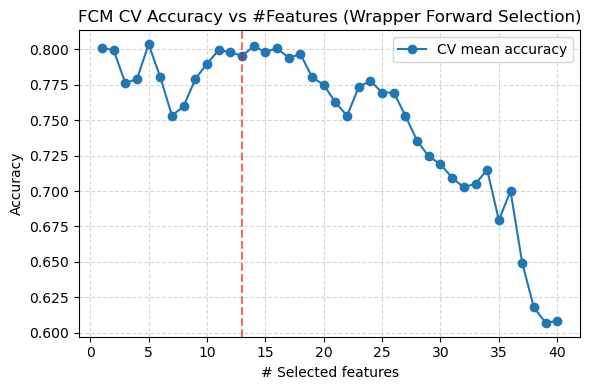

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import skfuzzy as fuzz


# ---------- Metrics ----------
def cluster_accuracy(y_true, y_pred):
    """Accuracy after optimal cluster↔class assignment via Hungarian algorithm."""
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()


# ---------- FCM helpers ----------
def _fcm_memberships_from_centers(X, centers, m=2.0, eps=1e-12):
    """
    Compute FCM memberships for X given learned centers (no refit).
    Returns U with shape (c, n_samples).
    """
    X = np.asarray(X)
    C = np.asarray(centers)
    d = np.linalg.norm(X[None, :, :] - C[:, None, :], axis=2) + eps  # (c, n)

    exact = np.isclose(d, eps)
    if exact.any():
        U = np.zeros_like(d)
        closest = np.argmin(d, axis=0)
        U[closest, np.arange(X.shape[0])] = 1.0
        mask = (U.sum(axis=0) == 0)
        if mask.any():
            dm = d[:, mask]
            p = 2.0 / (m - 1.0)
            ratio = (dm[:, None, :] / dm[None, :, :]) ** p
            denom = ratio.sum(axis=1)
            U[:, mask] = 1.0 / denom
        return U

    p = 2.0 / (m - 1.0)
    ratio = (d[:, None, :] / d[None, :, :]) ** p
    denom = ratio.sum(axis=1)
    return 1.0 / denom


def _fcm_cv_score(X, y, subset, *, k, cv, random_state, m, error, maxiter):
    """
    Mean/std CV accuracy for FCM on a given feature subset.
    Fits FCM on train folds; predicts memberships on validation folds using learned centers.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    rng = np.random.RandomState(random_state) if random_state is not None else None

    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr = X.iloc[tr_idx][subset].to_numpy()
        X_va = X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        # scale within fold
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        # skfuzzy expects (features, samples)
        Xtr_f = X_tr.T

        # reproducible soft-init U0
        if rng is not None:
            U0 = rng.rand(k, Xtr_f.shape[1])
            U0 /= U0.sum(axis=0, keepdims=True)
        else:
            U0 = None

        cntr, Utr, *_ = fuzz.cluster.cmeans(
            Xtr_f, c=k, m=m, error=error, maxiter=maxiter, init=U0
        )

        # predict on validation using learned centers
        Uva = _fcm_memberships_from_centers(X_va, cntr, m=m)
        y_pred = Uva.argmax(axis=0)
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_fcm_accuracy_cv(X_train: pd.DataFrame,
                            y_train: np.ndarray,
                            *,
                            k: int | None = None,
                            n_features_to_select: int = 15,
                            mode: str = "fixed",           # "fixed" → run full; "auto" → early stop on no-improve
                            random_state: int | None = 31,
                            select_set: int | str = 10,    # int step to return, or "best"
                            cv: int = 5,
                            m: float = 2.0,
                            error: float = 0.005,
                            maxiter: int = 1000):
    """
    Forward feature selection for FCM scored by cross-validated accuracy.
    Returns
    -------
    X_train_best : pd.DataFrame
    chosen_features : list[str]
    chosen_cv_mean : float
    history : list[dict] with keys {"step","feature_added","cv_mean","cv_std"}
    """
    if k is None:
        k = len(np.unique(y_train))

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)
        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            cv_mean, cv_std = _fcm_cv_score(
                X_train, y_train, subset,
                k=k, cv=cv, random_state=random_state,
                m=m, error=error, maxiter=maxiter,
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })
        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # choose subset to return
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]
    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


# ===== Example usage + plot =====
X_train_fcm_best, subset_fcm, best_cv_fcm, hist_fcm = wrapper_fcm_accuracy_cv(X_train_fs, 
                                                                              y_train_num,
                                                                              k=5,
                                                                              n_features_to_select=40,
                                                                              mode="fixed",
                                                                              random_state=31,
                                                                              select_set=13,   # or "best"
                                                                              cv=5,
                                                                              m=2.0,
                                                                              error=0.005,
                                                                              maxiter=1000)

print("Best subset (FCM):", subset_fcm)
print("Best CV mean accuracy (FCM):", best_cv_fcm)

# Plot CV mean only
steps = [h["step"] for h in hist_fcm]
cv_means = [h["cv_mean"] for h in hist_fcm]
cv_stds  = [h["cv_std"] for h in hist_fcm]

plt.figure(figsize=(6,4))
line, = plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_fcm)
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("FCM CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the Fuzzy C-Mean Clustering Model


Train Accuracies for k=1..5 (FCM): {1: 0.5252387448840382, 2: 0.810368349249659, 3: 0.7803547066848567, 4: 0.7762619372442019, 5: 0.6493860845839018}

Fuzzy C-Means (k=5) - TRAIN Results:
  Accuracy: 0.7913
  F1 Score: 0.6035
  Kappa:    0.6946

Fuzzy C-Means (k=5) - TEST Results:
  Accuracy: 0.8022
  F1 Score: 0.6061
  Kappa:    0.7087


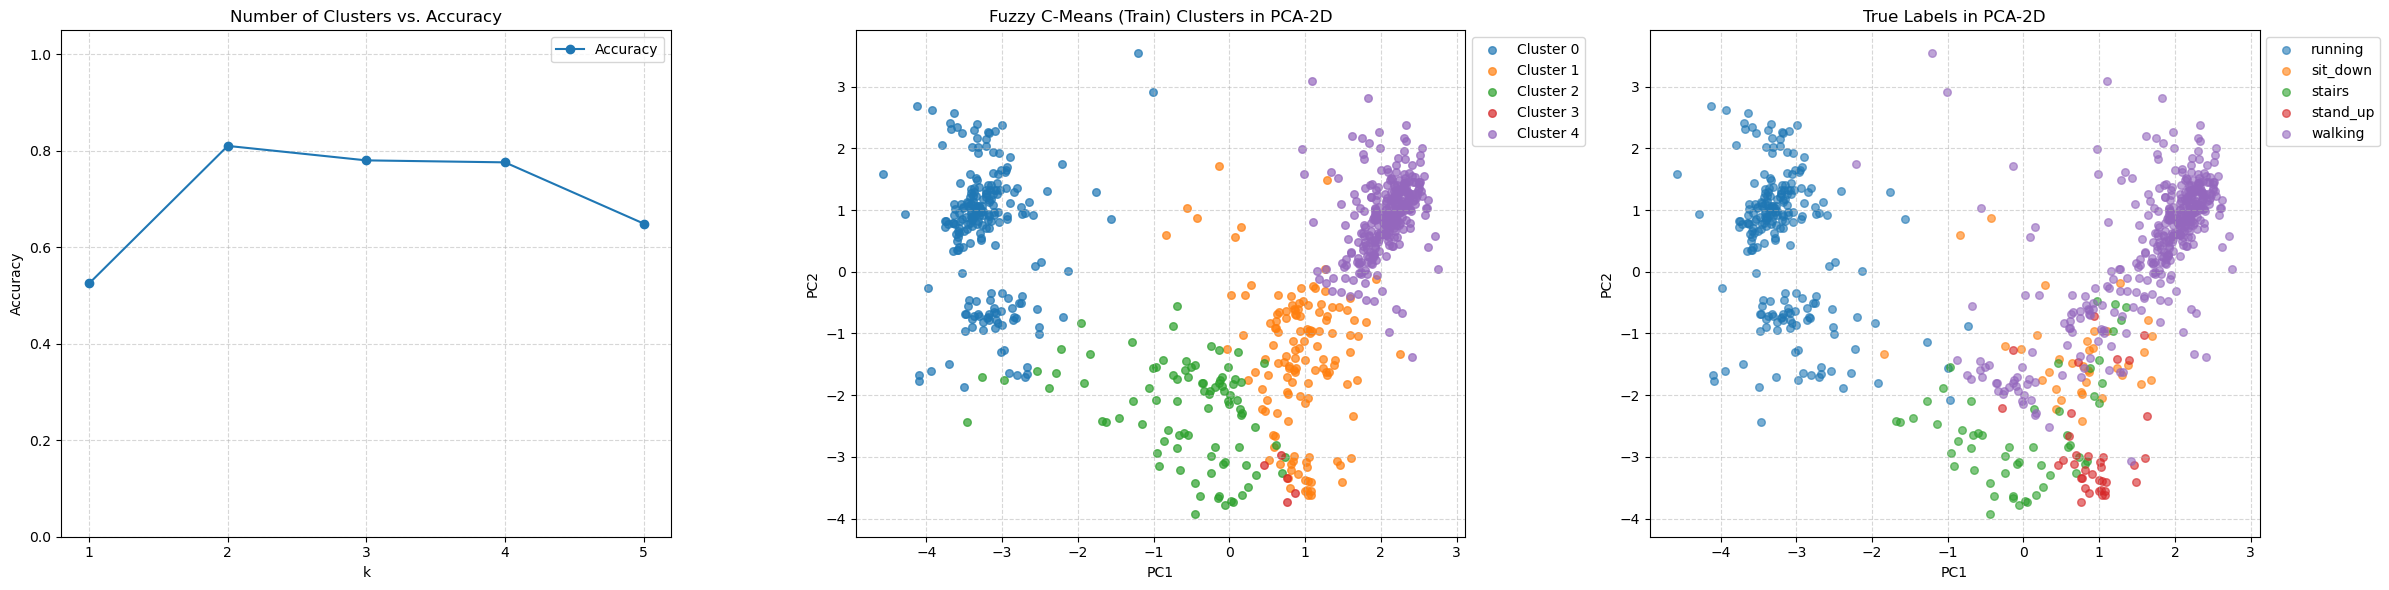

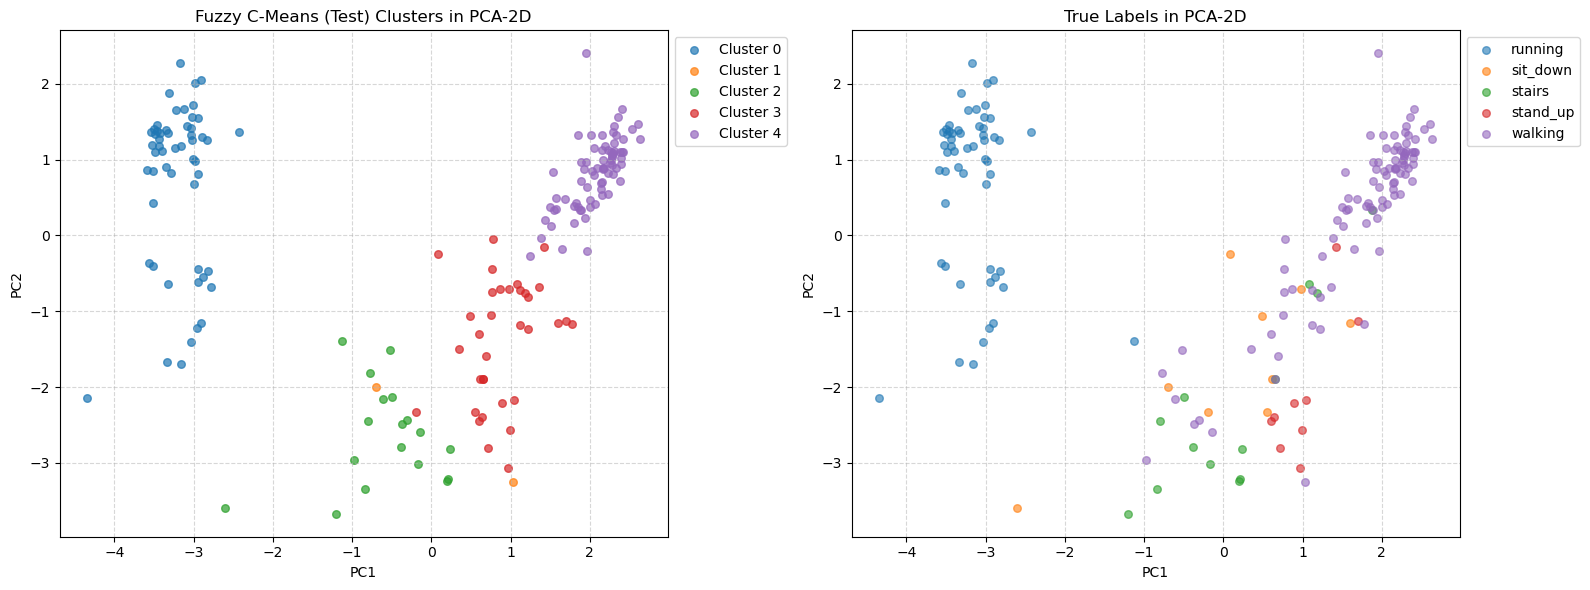

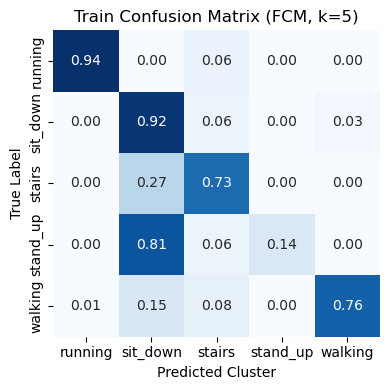

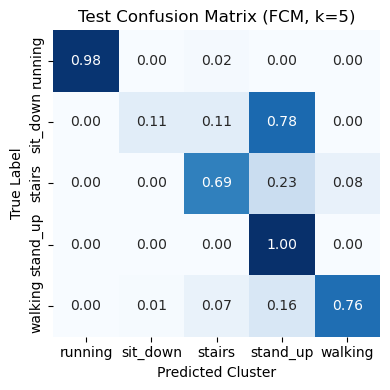

In [44]:
cluster_range = range(1, 6)
fcm_results = []
X_test_fcm_best = X_test_fs[subset_fcm]
# Reproducible init for cmeans
rng = np.random.RandomState(42)

for k in cluster_range:
    # skfuzzy.cmeans expects (features, samples)
    Xtr = X_train_fcm_best.to_numpy().T
    # reproducible random membership init U0
    U0 = rng.rand(k, Xtr.shape[1])
    U0 /= U0.sum(axis=0, keepdims=True)

    cntr, Utr, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k, m=2.0, error=0.005, maxiter=1000, init=U0)
    clusters = Utr.argmax(axis=0)  # hard labels
    fcm_results.append(clusters)

# Train accuracies for each k (after alignment)
accuracies = []
for clusters in fcm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (FCM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5

# Fit FCM on train (k=5) with reproducible init
Xtr = X_train_fcm_best.to_numpy().T
U0 = rng.rand(k_final, Xtr.shape[1]); U0 /= U0.sum(axis=0, keepdims=True)
cntr_final, Utr_final, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k_final, m=2.0, error=0.005, maxiter=1000, init=U0)

clusters_train = Utr_final.argmax(axis=0)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("Fuzzy C-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict clusters for TEST using learned centers
Ute_final = _fcm_memberships_from_centers(X_test_fcm_best.to_numpy(), cntr_final, m=2.0)
clusters_test = Ute_final.argmax(axis=0)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("Fuzzy C-Means (k=5) - TEST", y_test_num, y_test_aligned)

# Plot
plot_clustering_results("Fuzzy C-Means (Train)",
                        X_train_fcm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("Fuzzy C-Means (Test)",
                        X_test_fcm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (FCM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (FCM, k=5)", cmap='Blues')


### Gaussian Mixture Models (GMMs)

Gaussian Mixture Model Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for GMM.

Step 1 | +gyro_z_dom_freq | cv_mean=0.802 ± 0.006
Step 2 | +acc_y_median | cv_mean=0.806 ± 0.008
Step 3 | +acc_y_spec_centroid | cv_mean=0.813 ± 0.007
Step 4 | +acc_y_spec_entropy | cv_mean=0.828 ± 0.014
Step 5 | +acc_mag_spec_centroid | cv_mean=0.847 ± 0.022
Step 6 | +grav_corr_y_z | cv_mean=0.829 ± 0.024
Step 7 | +grav_mag_min | cv_mean=0.832 ± 0.031
Step 8 | +acc_z_max | cv_mean=0.832 ± 0.008
Step 9 | +gyro_x_spec_centroid | cv_mean=0.834 ± 0.025
Step 10 | +grav_mag_max | cv_mean=0.843 ± 0.014
Step 11 | +acc_mag_iqr | cv_mean=0.851 ± 0.008
Step 12 | +gyro_mag_spec_centroid | cv_mean=0.849 ± 0.031
Step 13 | +gyro_z_skew | cv_mean=0.839 ± 0.013
Step 14 | +acc_mag_dom_freq | cv_mean=0.849 ± 0.004
Step 15 | +gyro_corr_y_z | cv_mean=0.850 ± 0.014
Step 16 | +acc_y_dom_freq | cv_mean=0.857 ± 0.015
Step 17 | +gyro_x_dom_freq | cv_mean=0.854 ± 0.015
Step 18 | +acc_z_min | cv_mean=0.869 ± 0.021
Step 19 | +gyro_mag_dom_freq | cv_mean=0.854 ± 0.015
Step 20 | +gyro_y_dom_freq | cv_mean=0.846 ± 0

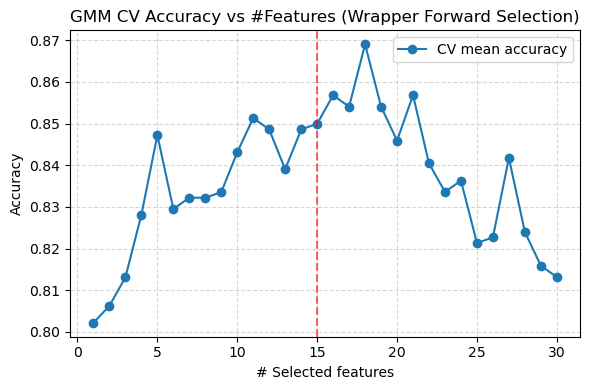

In [39]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment


# --- metric (same as before) ---
def cluster_accuracy(y_true, y_pred):
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()


# --- CV scorer for a given feature subset ---
def _gmm_cv_score(X, y, subset, *, k, cv, random_state, gmm_kwargs):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []

    for tr_idx, va_idx in skf.split(X, y):
        X_tr = X.iloc[tr_idx][subset].to_numpy()
        X_va = X.iloc[va_idx][subset].to_numpy()
        y_va = y[va_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_va = scaler.transform(X_va)

        gmm = GaussianMixture(n_components=k, random_state=random_state, **gmm_kwargs)
        gmm.fit(X_tr)
        y_pred = gmm.predict(X_va)          # argmax posterior
        scores.append(cluster_accuracy(y_va, y_pred))

    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1) if len(scores) > 1 else 0.0)


def wrapper_gmm_accuracy_cv(X_train: pd.DataFrame,
                            y_train: np.ndarray,
                            *,
                            k: int | None = None,
                            n_features_to_select: int = 15,
                            mode: str = "fixed",              # "auto" → early stop on no-improve
                            random_state: int = 42,
                            select_set: int | str = 10,       # step to return, or "best"
                            cv: int = 5,
                            gmm_kwargs: dict | None = None):
    """
    Forward feature selection for Gaussian Mixture Models scored by CV accuracy.

    Returns
    -------
    X_train_best, chosen_features, chosen_cv_mean, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if gmm_kwargs is None:
        gmm_kwargs = {}

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected: list[str] = []
    history: list[dict] = []

    for step in range(1, max_steps + 1):
        trial_scores = []  # (cv_mean, feature, cv_std)

        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            cv_mean, cv_std = _gmm_cv_score(
                X_train, y_train, subset,
                k=k, cv=cv, random_state=random_state, gmm_kwargs=gmm_kwargs
            )
            trial_scores.append((cv_mean, f, cv_std))

        if not trial_scores:
            break

        trial_scores.sort(key=lambda t: t[0], reverse=True)
        cv_mean, best_f, cv_std = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "cv_mean": float(cv_mean),
            "cv_std": float(cv_std),
        })
        print(f"Step {step} | +{best_f} | cv_mean={cv_mean:.3f} ± {cv_std:.3f}")

        if mode == "auto":
            prev = history[-2]["cv_mean"] if len(history) > 1 else -np.inf
            if cv_mean <= prev:
                print("No improvement on CV mean; early stop.")
                break

    # choose subset to return
    if select_set == "best":
        chosen_step = int(np.argmax([h["cv_mean"] for h in history])) + 1
    elif isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        chosen_step = len(history)

    chosen_features = [h["feature_added"] for h in history][:chosen_step]
    chosen_cv_mean = history[chosen_step - 1]["cv_mean"]
    X_train_best = X_train[chosen_features]

    return X_train_best, chosen_features, float(chosen_cv_mean), history


# ===== Example usage + plot =====
X_train_gmm_best, subset_gmm, best_cv_gmm, hist_gmm = wrapper_gmm_accuracy_cv(X_train_fs, y_train_num,
                                                                              k=5,
                                                                              n_features_to_select=30,
                                                                              mode="fixed",
                                                                              random_state=31,
                                                                              select_set=15,                    # or "best"
                                                                              cv=3,
                                                                              gmm_kwargs={"covariance_type": "full", "n_init": 5, "reg_covar": 1e-6})

print("Best subset (GMM):", subset_gmm)
print("Best CV mean accuracy (GMM):", best_cv_gmm)

# Plot CV mean only
steps = [h["step"] for h in hist_gmm]
cv_means = [h["cv_mean"] for h in hist_gmm]
cv_stds  = [h["cv_std"] for h in hist_gmm]

plt.figure(figsize=(6,4))
line, = plt.plot(steps, cv_means, marker='o', label="CV mean accuracy")
sel = len(subset_gmm)
plt.axvline(sel, linestyle="--", alpha=0.6, color="red")
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("GMM CV Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the GMM Clustering Model


Train Accuracies for k=1..5 (GMM): {1: 0.5252387448840382, 2: 0.8117326057298773, 3: 0.8581173260572987, 4: 0.7639836289222374, 5: 0.7680763983628922}

GMM (k=5) - TRAIN Results:
  Accuracy: 0.8090
  F1 Score: 0.5693
  Kappa:    0.7030

GMM (k=5) - TEST Results:
  Accuracy: 0.8352
  F1 Score: 0.5865
  Kappa:    0.7397


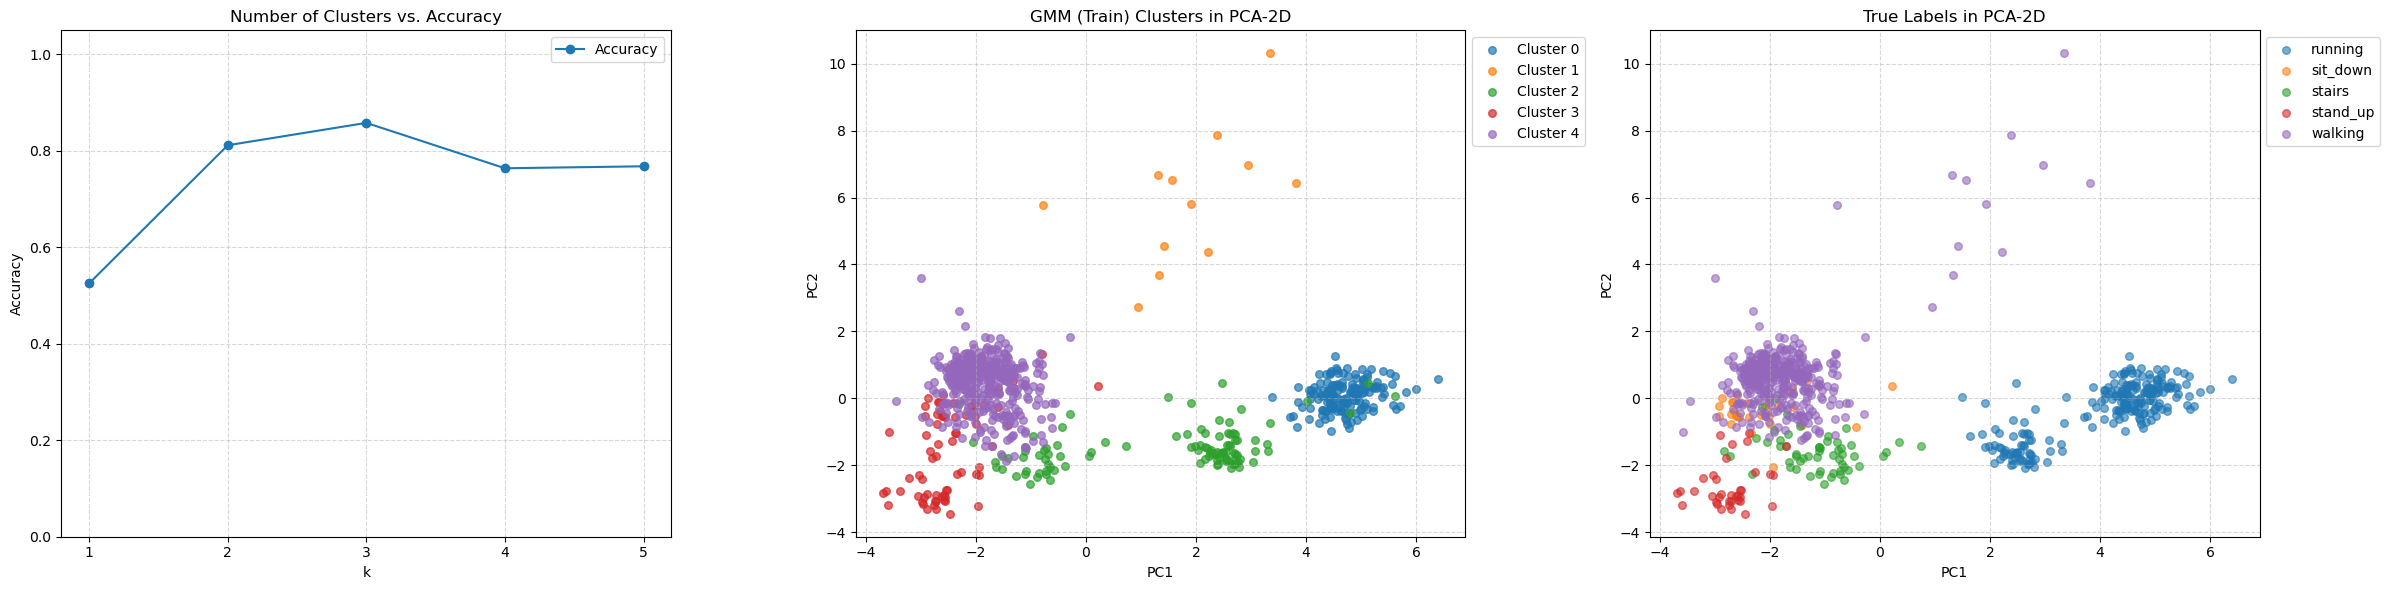

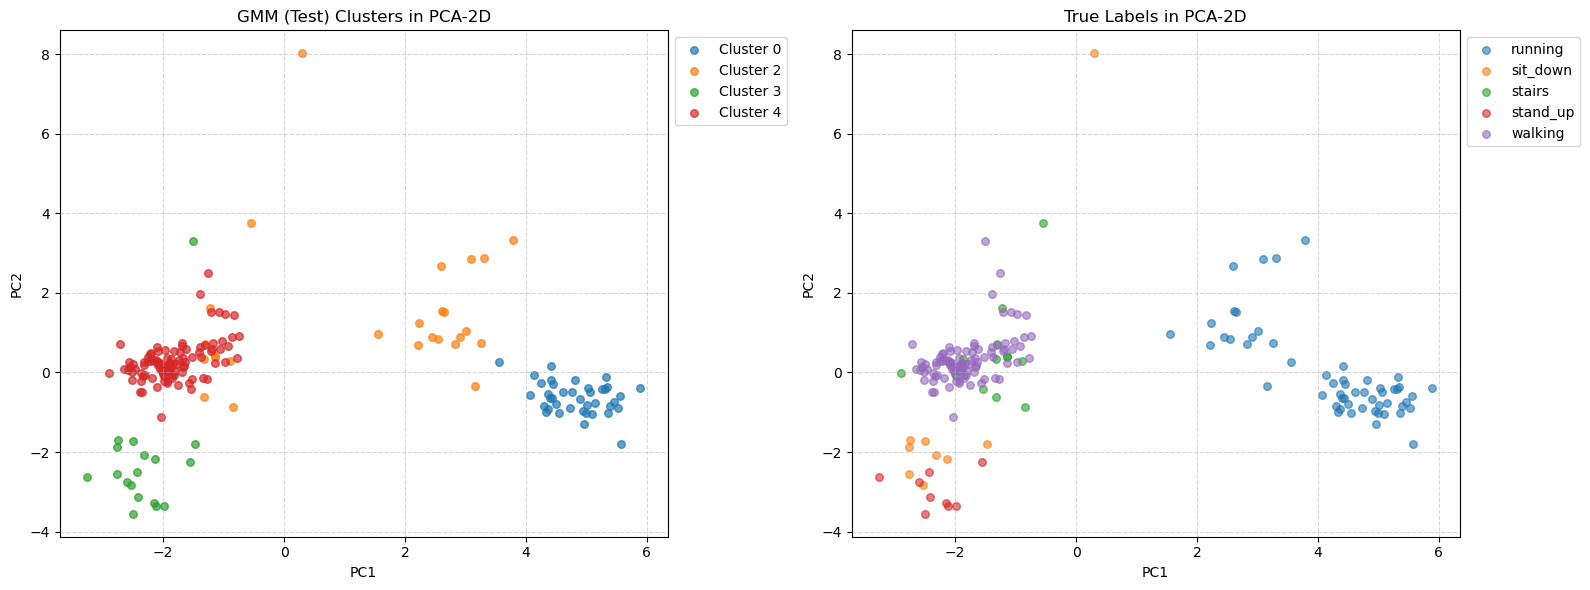

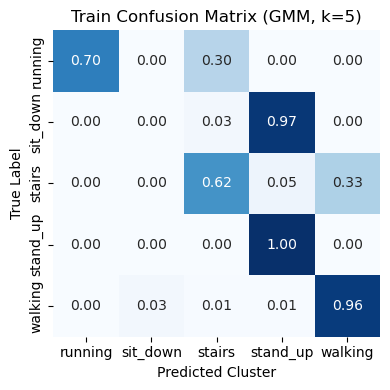

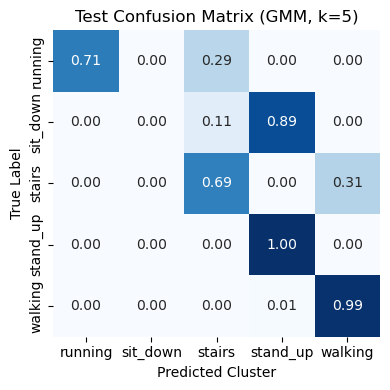

In [46]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix

cluster_range = range(1, 6)
gmm_results = []
X_test_gmm_best = X_test_fs[subset_gmm]
rng = np.random.RandomState(42)  # for reproducibility of GMM init params

for k in cluster_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-6,           
        n_init=10,                
        random_state=42
    )
    gmm.fit(X_train_gmm_best)
    clusters = gmm.predict(X_train_gmm_best)
    gmm_results.append(clusters)

# Train accuracies
accuracies = []
for clusters in gmm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (GMM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5
gmm_final = GaussianMixture(n_components=k_final,
                            covariance_type="full",
                            reg_covar=1e-6,
                            n_init=1,
                            random_state=42)
gmm_final.fit(X_train_gmm_best)

# Train evaluation
clusters_train = gmm_final.predict(X_train_gmm_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("GMM (k=5) - TRAIN", y_train_num, y_train_aligned)

# Test evaluation
clusters_test = gmm_final.predict(X_test_gmm_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("GMM (k=5) - TEST", y_test_num, y_test_aligned)

# Plots
plot_clustering_results("GMM (Train)",
                        X_train_gmm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("GMM (Test)",
                        X_test_gmm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (GMM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (GMM, k=5)", cmap='Blues')

In [ ]:
#sdsd